## Algorithms and Structural Estimation
---

*Empirical Methods for Economics and Business*

Zhiyuan Chen 

**Renmin Business School** 

2025-5-23


## Roadmap 

* [**Algorithms with Economics Applications**](#Algorithms-with-Economics-Applications)
  * Solving System of Equations 

  * Gradient Descent-Based Algorithms for Minimization Problems
  
  * Numerical Differentiation and Integration
  
  * Raw Fix-Point-based Iterations 
  
* [**Introduction to Structural Estimation**](#introduction-to-structural-estimation-in-economics)
  * Maximum Likelihood Estimation (MLE)
  
  * Generalized Method of Moments (GMM)
  
  * Simulated Method of Moments (SMM)

# Algorithms with Economics Applications
---

### Solving System of Equations 
---
Consider a function $f: \mathbf{R}^n\rightarrow \mathbf{R}^n$, our objective is to find the root such that
$$\large
f(x) = \mathbf{0}
$$

* Market clearing conditions in macro models 
  
* Equilibrium conditions in game theory 
  
* Optimality conditions in constrained optimization problems

#### Newton's Method 

Newton's method iterations are derived from a first-order Taylor approximation: 

$$ f(x) \approx f(x^{(k)}) + f'(x^{(k)})(x - x^{(k)}) = 0 $$

Solve for $x^{(k+1)}$ to get the iteration rule: 

$$ x^{(k)} - [f'(x^{(k)})]^{-1}f(x^{(k)}) \rightarrow x^{(k+1)}  $$

For Newton's Method to work we need: 

* $f$ is continuously differentiable.  
* $f(x^{(0)})$ is sufficiently close to a root. 
* $f'$ is invertible at the root.

### Extensions of Newton's Method 

#### Secant Method
> **Secant Method**: Newton method is costly when jacobian is hard to compute. Suppose $f : R \rightarrow R$ is __univariate__.  The secant method iteration just replaces the derivative in Newtons
method with a secant approximation: 
> $$\large x^{(k)} - \underbrace{\frac{ x^{(k)} - x^{(k-1)} }{ f(x^{(k)})
    - f(x^{(k-1)}) }}_{secant} f(x^{(k)})\rightarrow x^{(k+1)}$$

#### Broyden's Method (Optional)
* **Broyden's Method**: Generalization of secant method to multivariate case $f: \mathbf{R}^n\rightarrow \mathbf{R}^n$ The idea is to replace the Jacobian with a secant approximation. 

* Need to solve the following linear system:
  $$ f(x^{(k)}) - f(x^{(k-1)}) = J^{(k)} (x^{(k)} - x^{(k-1)}) $$
  * $J^{(k)}$ is undetermined when $n>1$. 
* Broyden proposes to use the current estimate of the Jacobian matrix $J^{k}$ and improve it by minimizing the following __Frobenius norm__: $$  J^{(k+1)} = J^{(k)} + \Delta J^{(k)}\Rightarrow \min \|\Delta J^{(k)}\|_F$$
  Which implies $$\Delta J^{(k)} [f(x^{(k+1)}) - f(x^{(k)})] = (x^{(k+1)} - x^{(k)})-J^{(k)} [f(x^{(k+1)}) - f(x^{(k)})]$$
    * Solving the Optimization problem gives us the update rule for the Jacobian matrix [(See Appendix)](#Jacobian-Matrix-in-Broyden's-Method): $$(J^k)^{-1} = (J^{k-1})^{-1}+\frac{\Delta x^k-(J^{k-1})^{-1}\Delta f^k}{(\Delta x^k)'(J^{k-1})^{-1}\Delta f^{k}}\Delta (x^k)'(J^k)^{-1}$$
    * The __Frobenius norm (福罗贝尼乌斯范数, F范数)__ or the __Hilbert-Schimidt norm (希尔伯特-斯密特范数)__ is defined as:$$\|A\|_F = \sqrt{\sum_i^m \sum_j^n|a_{ij}|^2} $$

### Economic Application I: Solow Growth Model
---
* In the Solow growth model, assuming Cobb-Douglas production technology and
zero population growth, the law of motion for capital is $$k_{t+1} = g(k_t) \quad \text{where} \quad g(k) := sAk^\alpha + (1-\delta) k \tag{law-of-motion}$$
  - $ k_t $ is capital stock per worker,   $ A, \alpha>0 $ are production parameters, $ \alpha<1 $, $ s>0 $ is a savings rate, and  $ \delta \in(0,1) $ is a rate of depreciation  

* **Goal**: calculate the unique [steady state](https://en.wikipedia.org/wiki/Steady_state) for the capital: $ k^* > 0 $ such that $ g(k^*)=k^* $.
  - since $ k_t = k^* $ implies $ k_{t+1} = k^* $.  

* **Analytical Solution**: solve $ g(k)=k $, you will be able to confirm that
$$
k^* = \left(\frac{s A}{δ}\right)^{1/(1 - α)}
$$

* **Numerical Solution**: we use the Newton's method to find the root of the function $f(k) = g(k) - k$: $$\large k^{(i+1)} = k^{(i)} - \frac{f(k^{(i)})}{f'(k^{(i)})} $$

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pandas as pd
from IPython.display import HTML
import time 
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
from collections import namedtuple 
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
#Solving Solow Growth Model using Gradient Descent-based Method 
SolowParameters = namedtuple("SolowParameters", ('A', 's', 'α', 'δ')) 

def create_solow_params(A=2.0, s=0.3, α=0.3, δ=0.4):
    "Creates a Solow model parameterization with default values."
    return SolowParameters(A=A, s=s, α=α, δ=δ)
#define the law-of-motion function
def g(k, params):
    A, s, α, δ = params
    return A * s * k**α + (1 - δ) * k
#define the analytical steady-state solution  
def exact_fixed_point(params):
    A, s, α, δ = params
    return ((s * A) / δ)**(1/(1 - α))

#plot the law-of-motion function and the 45-degree line
def plot_45(params, ax, fontsize=14):
    k_min, k_max = 0.0, 3.0
    k_grid = np.linspace(k_min, k_max, 1200)
    # Plot the functions
    lb = r"$g(k) = sAk^{\alpha} + (1 - \delta)k$"
    ax.plot(k_grid, g(k_grid, params),  lw=2, alpha=0.6, label=lb)
    ax.plot(k_grid, k_grid, "k--", lw=1, alpha=0.7, label="45-degree")
    # Show and annotate the fixed point
    kstar = exact_fixed_point(params)
    fps = (kstar,)
    ax.plot(fps, fps, "go", ms=10, alpha=0.6)
    ax.annotate(r"$k^* = (sA / \delta)^{\frac{1}{1-\alpha}}$", 
             xy=(kstar, kstar),
             xycoords="data",
             xytext=(20, -20),
             textcoords="offset points",
             fontsize=fontsize)
    ax.legend(loc="upper left", frameon=False, fontsize=fontsize)
    ax.set_title(r"Parameters: A = {:.2f}, s = {:.2f}, α = {:.2f}, δ = {:.2f}".format(params.A, params.s, params.α, params.δ), fontsize=fontsize)
    ax.set_yticks((0, 1, 2, 3))
    ax.set_yticklabels((0.0, 1.0, 2.0, 3.0), fontsize=fontsize)
    ax.set_ylim(0, 3)
    ax.set_xlabel("$k_t$", fontsize=fontsize)
    ax.set_ylabel("$k_{t+1}$", fontsize=fontsize)

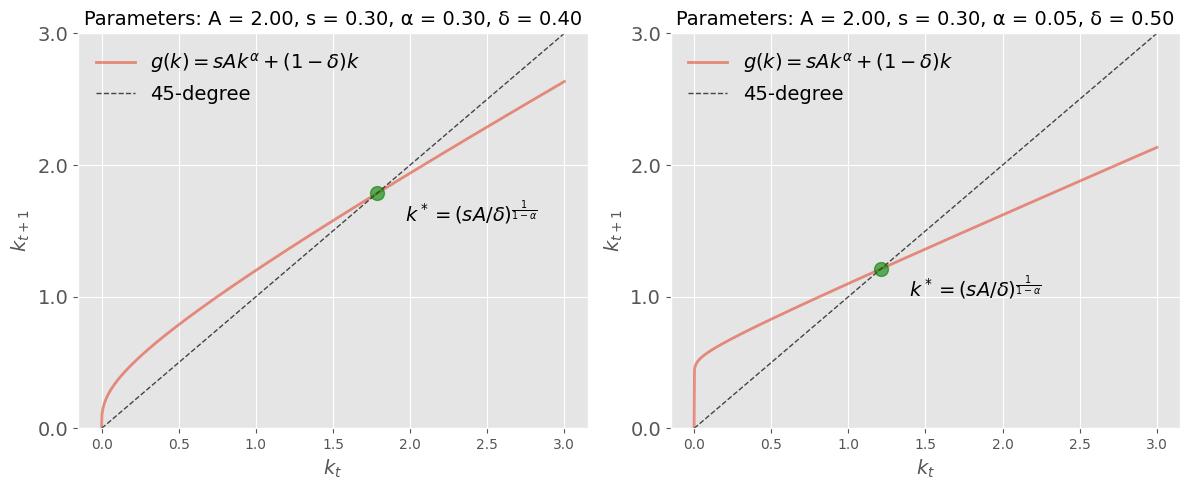

In [211]:
# Diagrams and Analytical Solution for two parameterizations of the Solow model
params1 = create_solow_params()
params2 = create_solow_params(α=0.05, δ=0.5)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plot_45(params1, axs[0])
plot_45(params2, axs[1])
plt.tight_layout()
plt.show()

True Steady State: k* = 1.7847
Newton-Method:
Converged to k = 1.7846
Minimal Functional Value =1.7846
Number of iterations = 60


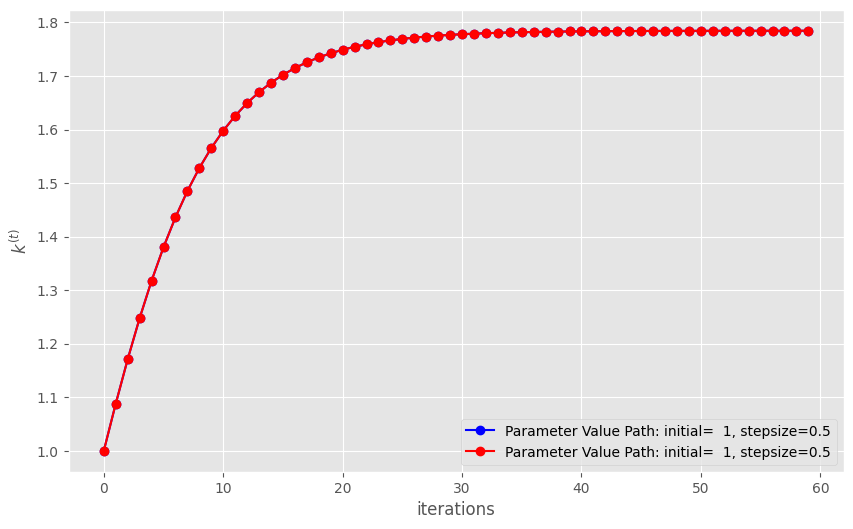

In [213]:
# Using the gradient descent method to solve the Solow model
## Step 0 - Define the Gradient and Hessian 
def Gradg(k, params):
    A, s, α, δ = params
    return 2*(s*A*k**α - δ*k)*(s*A*α*k**(α-1) - δ) 
## Step 1 - Update the parameters
## initialization 
k0 = 1 #initials 
tol = 1e-5 #tolerance for convergence 
##Gradient Descent Method 
k = k0 
k_list = [k]
funv_list = [g(k, params)]
while True:
    k_new = k - Gradg(k, params)
    k_list.append(k_new)
    funv_list.append(g(k_new, params))
    if abs(k_new - k) < tol:
        break
    k = k_new

print("True Steady State: k* = {:.4f}".format(exact_fixed_point(params)))
print('Newton-Method:')
print('Converged to k = {:.4f}'.format(k))
print('Minimal Functional Value ={:.4f}'.format(g(k, params)))
print('Number of iterations =', len(funv_list))
#plot the path of k and function value
plt.plot(k_list, 'o-', color='blue', label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(k0, stepsize))
plt.xlabel('iterations')
plt.ylabel('$k^{(t)}$')
#plot the path of k and function value
plt.plot(k_list, 'o-', color='red', label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(k0, stepsize))
plt.xlabel('iterations')
plt.ylabel('$k^{(t)}$')
plt.legend()
plt.show()


## Gradient Descent Algorithms



**Optimization Problem**: For $f: \mathbb{R}^n \rightarrow \mathbb{R}$ $$\min_{\theta} f(\theta)$$
 * $f(\theta)$ is differentiable, e.g., loss function 
 * $\theta$ is continuous 

**Gradient Descent (梯度下降)**: A first-order iterative optimization algorithm for finding the minimum of an objective function. 
$$ \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla_{\theta} f(\theta^{(k)})$$
  * $\alpha_k$ is the **learning rate (step size)**
  * $\nabla f(\theta)$: gradient of the objective function
  * Widely used in structural estimation, machine learning and deep learning for optimizing loss functions.

**Goal**: *Move in the direction of steepest descent to find the minimum*


### Gradient Descent Algorithm (continued)

**Why Gradient Descent?**: Take the  Taylor expansion of $f(\theta)$ around $\theta^{(k)}$: 
\begin{aligned}
f(\theta) = & f(\theta^{(k)}) + \nabla_{\theta} f(\theta^{(k)})^T (\theta - \theta^{(k)}) \\
\Rightarrow f(\theta^{(k+1)}) = & f(\theta^{(k)}) + \nabla_{\theta} f(\theta^{(k)})^T (\theta^{(k+1)} - \theta^{(k)}) \\
{\footnotesize \text{plug in } \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla_{\theta} f(\theta^{(k)})} & \\
\Rightarrow f(\theta^{(k+1)}) = & f(\theta^{(k)}) - \alpha_k \|\nabla_{\theta} f(\theta^{(k)})\|^2 \leq f(\theta^{(k)})
\end{aligned}

It can be shown that the direction with $\alpha_k=1$ is the **steepest descent direction** ([See Appendix](#convergence-properties-of-gradient-descent-based-method)). 

---
> **Algorithm Steps**:

> 1. **Initialization**: Choose an initial value for $\theta^{(0)}$.

> 2. **Compute Gradient**: Calculate the gradient $\nabla_{\theta} f(\theta^{(k)})$ at the current point $\theta^{(k)}$.

> 3. **Update Parameters**: Update the parameters using the gradient and learning rate:
   $$ \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla_{\theta} f(\theta^{(k)})$$

> 4. **Convergence Check**: Check if the change in the objective function or parameters is below a certain threshold (i.e., $\|\nabla f(x)\|$ is small enough)

---

###  Extension 1: Stochastic Gradient Descent (SGD)
---

- For **large datasets**, computing full gradient $\nabla f(x)$ is expensive.

> **Updating Rule:** **SGD** uses a **random subset (mini-batch)** of data to approximate the gradient:$$
  \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla f_{i_k}(\theta^{(k)})$$ Where $f_{i_k}$ is the loss on a randomly chosen data point or batch.

- **Pros**: Faster updates and can escape shallow local minima

- **Cons**: Noisy convergence and requires tuning learning rate and batch size


### 🧮 Extension 2: Newton’s Method
---

- Use curvature information (second derivatives) for faster convergence

> **Update Rule for Newton's Method**: $$
\theta^{(k+1)} = \theta^{(k)} - [\nabla^2 f(\theta^{(k)})]^{-1} \nabla f(\theta^{(k)})$$

- **Pros**: **Quadratic convergence** near the optimum
  - **Quadratic convergence**: The number of correct digits in the approximation roughly doubles with each iteration.
  - [See Appendix](#Convergence-Properties-of-Newton's-Method) for the convergence properties of Newton's Method.
  
- **Cons**: 
  - Computationally expensive (inverse of Hessian)
  - Not suitable for high-dimensional problems


### Extension 3: Lagrangian Methods for Constrained Optimization
---
**Problem Formulation**:   $$ \min f(\theta)  \\ \text{ s.t. } g(\theta) = 0$$

- This problem can potentially be transformed into an unconstrained optimization problem by plugging the constraint into the objective function
  
- **Lagrangian function**: $$\mathcal{L}(\theta, \lambda) = f(\theta) + \lambda^T g(\theta)$$

- **Solve**: Find saddle point $(\theta ^*, \lambda^*)$ such that:
  $$
  \min_{\theta, \lambda} \mathcal{L}^2(\theta, \lambda) = [f(\theta) + \lambda^T g(\theta)]^2
  $$



###  Extension 4: Subgradient Methods
---

- For **non-smooth** functions where gradient does not exist, use a **subgradient** $g \in \partial f(\theta)$ in the updating rule: $$
\theta^{(k+1)} = \theta^{(k)} - \alpha_k g^{(k)}$$
  > **Subgradient**: A subgradient at a point $x_0$ is any slope $g$ such that $$f(x) \geq f(x_0) + g^T (x - x_0)$$ for all $x$ in the domain of $f$.

- Works for convex, non-differentiable functions (e.g. $f(x) = |x|$)
- Slower convergence compared to gradient methods


### Preparation for Programming: Do Loops in Python

* `while` loop: Repeats a block of code as long as a condition is true.

* `break`: Exits the loop immediately.
```python
while True:
    if condition:
        break  # Exit the loop
    # code block
```
* `for` loop: Iterates over a sequence (like a list or range).
```python
for i in range(n):
    # code block
```

* `continue`: Skips the current iteration and moves to the next one.
```python
for i in range(n):
    if condition:
        continue  # Skip this iteration
    # code block
```
* `else` in loops: Executes after the loop finishes, unless interrupted by a `break`.
```python
for i in range(n):
    if condition:
        break
else:
    # This block runs if the loop completes without a break
```

### Example: Gradient Descent & Newton's Method for Single-Variable Function 

* **Optimization problem**: $$\min_{\theta}f(\theta) = \theta^3 + \theta^2 + 1$$ 

* **Compute Gradient**: $$\nabla f(\theta) = 3\theta^2 + 2\theta$$

* **Update Rule**: $$\theta^{(k+1)} = \theta^{(k)} - \alpha_k (3(\theta^{(k)})^2 + 2\theta^{(k)})$$
  * For basic gradient descent, set $\alpha_k = 0.1$ and experiment with other values 
    * **Small** step sizes may lead to **slow convergence**
    * **Large** step sizes may lead to **divergence**
  * For Newton's method, set $$\alpha_k = \frac{1}{\nabla^2 f(\theta^{(k)})} = 6\theta^{(k)} + 2$$
  * For both methods, the choice of initial value matters. 

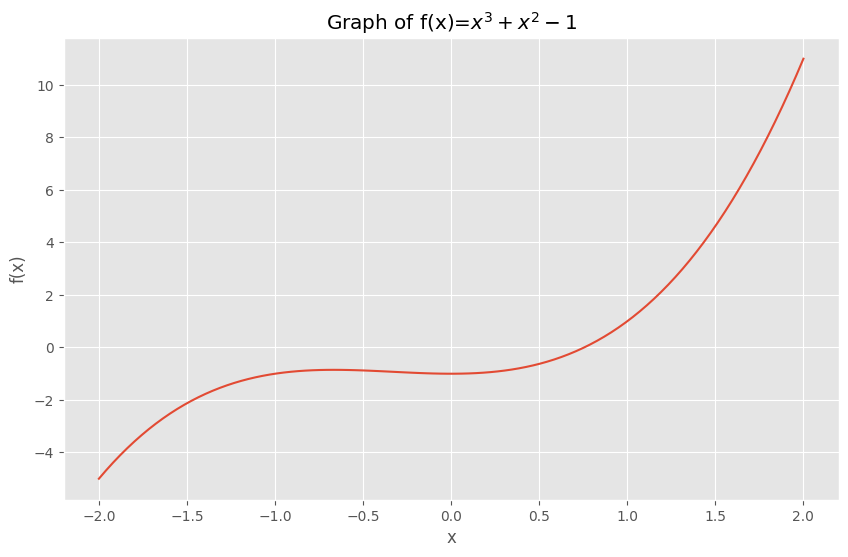

In [ ]:
# Gradient Descent for Quadratic Function Optimization 
#Functions and derivatives 
def f(x):
    return x**3 + x**2 - 1
def df(x):
    return 3*x**2 + 2*x
def d2f(x):
    return 6*x + 2
#Step 0 - plot the function 
x = np.linspace(-2, 2, 100)
y = f(x)
plt.plot(x, y)
plt.title('Graph of f(x)=$x^3+x^2-1$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

Running Time: 0.0001 秒
Converged to x = -1.2722131112823677e-05
Minimal Functional Value = -0.9999999998381495
Number of iterations = 26


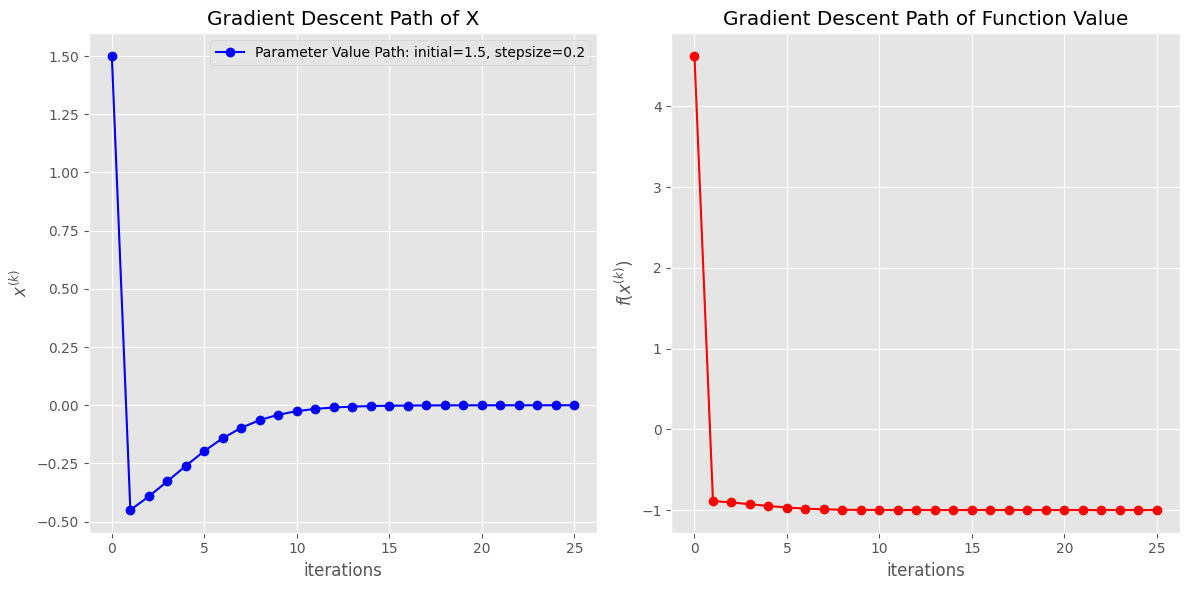

In [156]:
# Gradient Descent with Fixed Step Size and different initial points 
# Experiment 1: Step Size = 0.2, Initial Point 1 = 1.5
stepsize = 0.2 #learning rate 
x0 = 1.5 #initial point 1
tol = 1e-5 #tolerance for convergence
#iteration to solve the optimization problem
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#plot the path of x and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('$x^{(k)}$')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$f(x^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

In [159]:
#create an animation of the path of x and f(x)
fig, ax1 = plt.subplots(1, 1)
x = np.linspace(-1.5, 1.5, 100)
y = f(x)
ax1.plot(x, y)
line1, = ax1.plot([], [], 'o-', color='blue')
ax1.set_xlabel('x')
ax1.set_ylabel('$f(x)$')
ax1.set_title('Gradient Descent Path of X')
def update(frame):
    line1.set_data(x_list[:frame+1], funv_list[:frame+1])
    return line1, line2

ani = FuncAnimation(fig, update, frames=len(x_list), interval=300, blit=True)
plt.close(fig)  # Prevents the static plot from showing up
HTML(ani.to_jshtml())

Converged to x = -1200.4281542541562
Minimal Functional Value = -1728409259.6407516
Number of iterations = 6


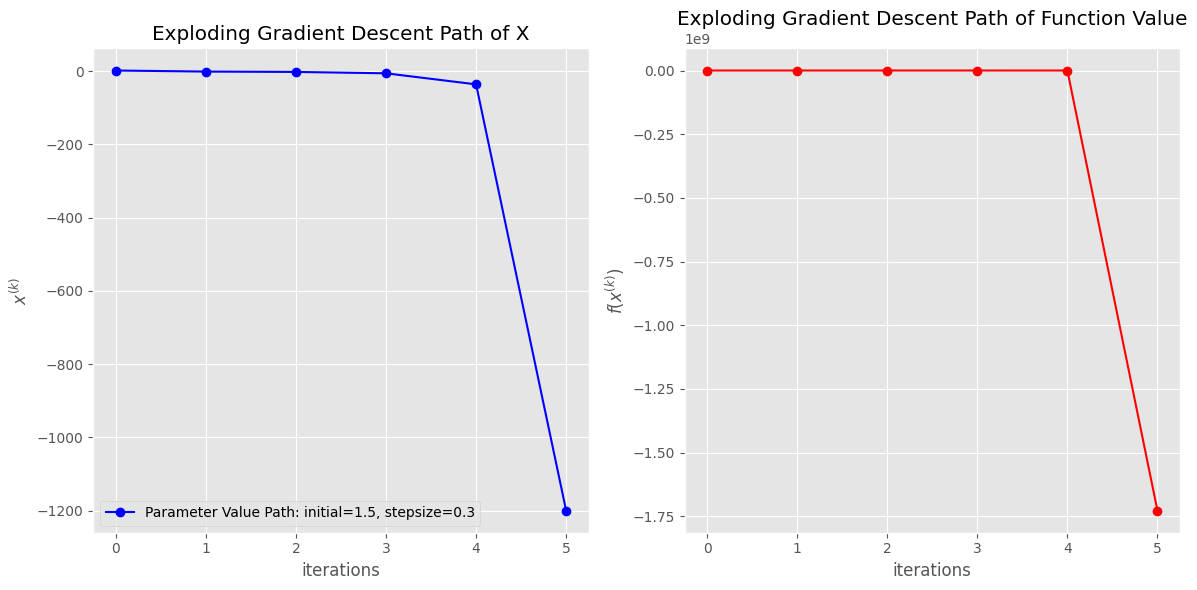

In [6]:
# Experiment 2: Step Size = 0.3, Initial Point 1 = 1.5
stepsize = 0.3 #learning rate 
x0 = 1.5 #initial point 1
tol = 1e-5 #tolerance for convergence
#iteration to solve the optimization problem
x = x0
funv_list = [f(x)]
x_list = [x]
Max_iter = 5
for i in range(Max_iter):
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#plot the path of x and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('$x^{(k)}$')
plt.legend()
plt.title('Exploding Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$f(x^{(k)})$')
plt.title('Exploding Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0005 秒
Converged to x = 0.0024770958995453335
Minimal Functional Value = -0.9999938487964338
Number of iterations = 1305


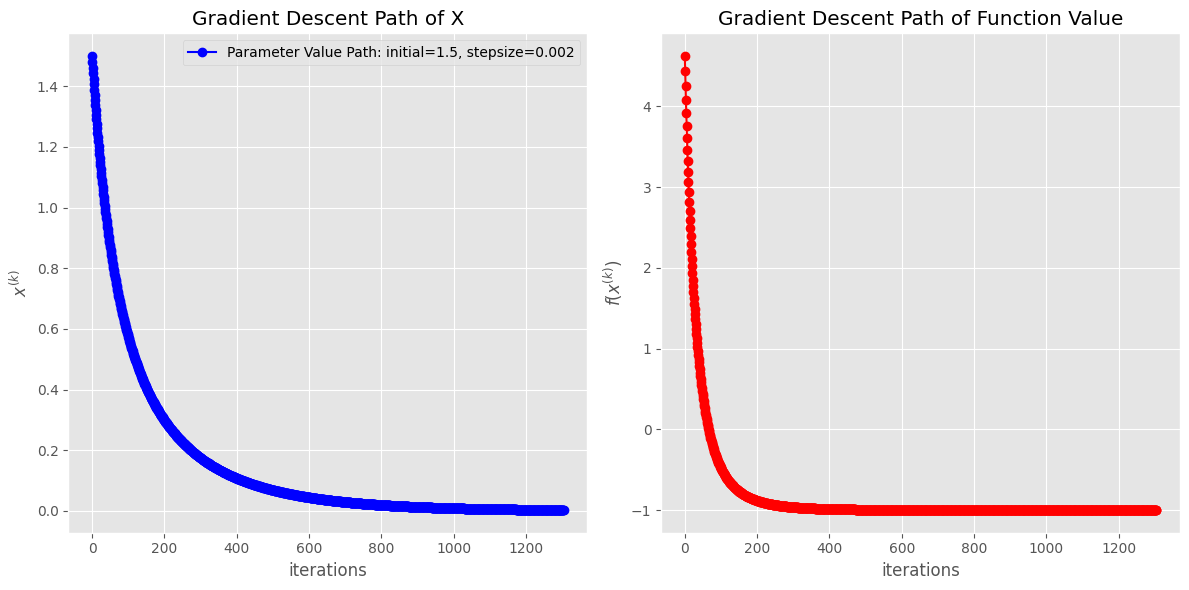

In [18]:
# Experiment 4: Step Size = 0.001, Initial Point = 1.5 
stepsize = 0.002 #learning rate 
x0 = 1.5 #initial point 1
tol = 1e-5 #tolerance for convergence
#iteration to solve the optimization problem
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#plot the path of x and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('$x^{(k)}$')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$f(x^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0001 秒
Converged to x = -6216.948322256572
Minimal Functional Value = -240249177714.18576
Number of iterations = 11


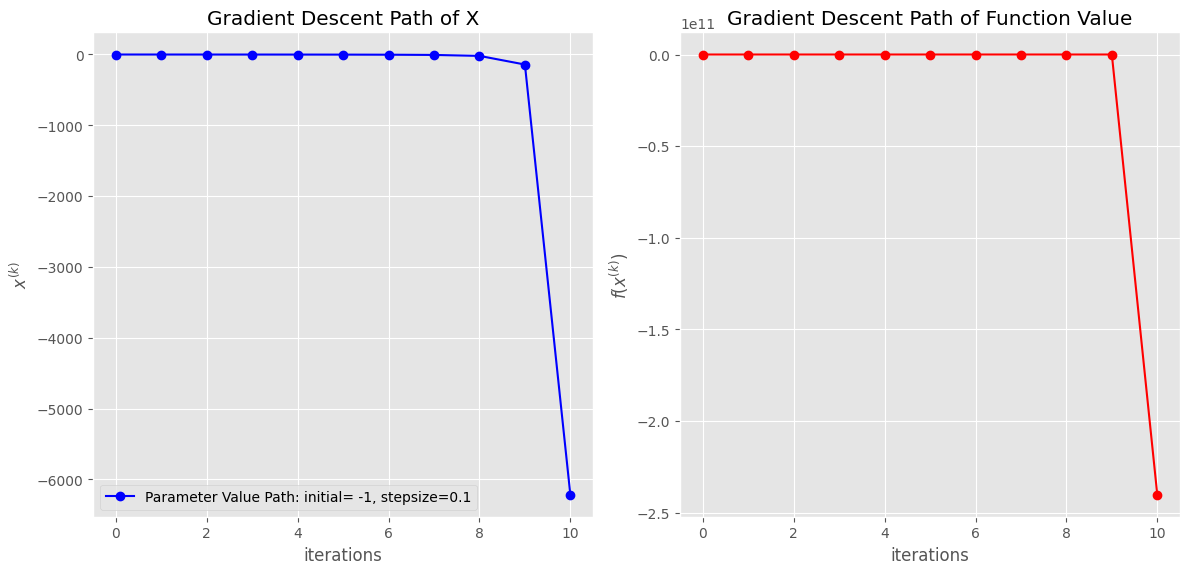

In [22]:
# Experiment 5: Step Size = 0.1, Initial Point = 1.5 
stepsize = 0.1 #learning rate 
x0 = -1 #initial point 1
tol = 1e-5 #tolerance for convergence
#iteration to solve the optimization problem
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
max_iter = 10
for i in range(max_iter):
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#plot the path of x and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('$x^{(k)}$')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$f(x^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0001 秒
Converged to x = 4.0091730049920005e-11
Minimal Functional Value = -1.0
Number of iterations = 7


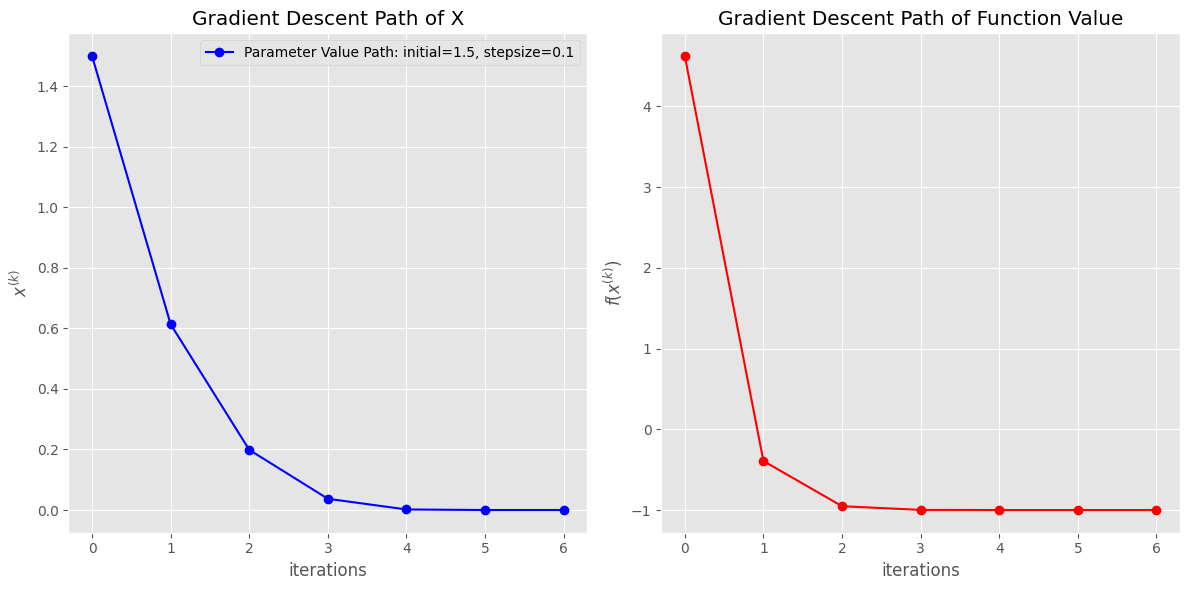

In [37]:
# Experiment 6: Netwon's Method with Initial Point = 1.5 
x0 = 1.5 #initial point 1
tol = 1e-5 #tolerance for convergence
#iteration to solve the optimization problem
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - 1/d2f(x)* df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#plot the path of x and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('$x^{(k)}$')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$f(x^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0002 秒
Converged to x = -0.6666666666666667
Minimal Functional Value = -0.8518518518518519
Number of iterations = 7


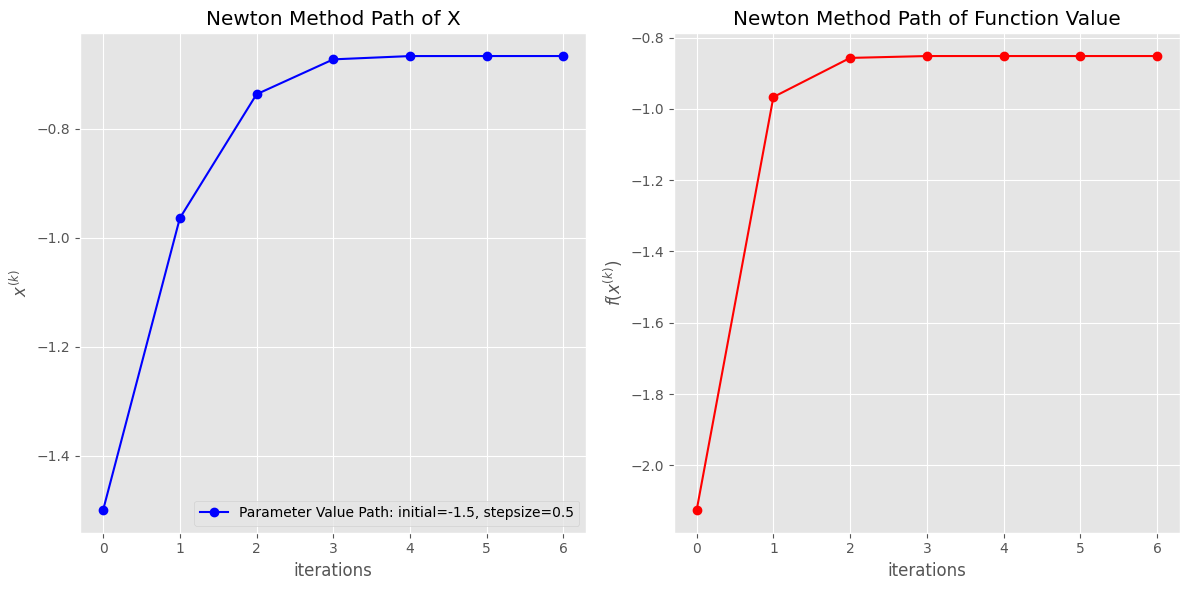

In [202]:
# Experiment 7: Netwon's Method with Initial Point = -1.5 (Stuck at local maximum) 
x0 = -1.5 #initial point 1
tol = 1e-5 #tolerance for convergence
#iteration to solve the optimization problem
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - 1/d2f(x)* df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#plot the path of x and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('$x^{(k)}$')
plt.legend()
plt.title('Newton Method Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$f(x^{(k)})$')
plt.title('Newton Method Path of Function Value')
plt.tight_layout()
plt.show()

## Example: Gradient Descent for Linear Regression

- **Regression Model**:  $$\large y = b + w x + \epsilon$$

- **Optimization Problem**: Minimize the **Mean Squared Error (MSE)** (loss function):
$$\large MSE(w, b) = \frac{1}{n} \sum_{i=1}^n [y_i - (b + w x_i)]^2$$

$$
\begin{bmatrix}
b^{(k+1)} \\
w^{(k+1)}
\end{bmatrix}
=
\begin{bmatrix}
b^{(k)} \\
w^{(k)}
\end{bmatrix}
-
\alpha_k
\begin{bmatrix}
\frac{\partial{\text{MSE}(b^{(k)}, w^{(k)})}}{\partial{b}} \\
\frac{\partial{\text{MSE}(b^{(k)}, w^{(k)})}}{\partial{w}}
\end{bmatrix}
$$


### Gradient and Hessian for Linear Regression 

- **Compute the Gradients**:
$$
\begin{aligned}
\frac{\partial{\text{MSE}}}{\partial{b}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{b}} &= \frac{2}{n} \sum_{i=1}^n{(b + w x_i - y_i)} 
\\
\frac{\partial{\text{MSE}}}{\partial{w}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{w}} &= \frac{2}{n} \sum_{i=1}^n{(b + w x_i - y_i) x_i} 
\end{aligned}
$$

- **Compute the Hessian**:
$$
\begin{aligned}
 H & = \begin{bmatrix}
\frac{\partial^2{\text{MSE}}}{\partial{b^2}} & \frac{\partial^2{\text{MSE}}}{\partial{b \partial{w}}} \$5pt]
\frac{\partial^2{\text{MSE}}}{\partial{w \partial{b}}} & \frac{\partial^2{\text{MSE}}}{\partial{w^2}} 
\end{bmatrix} \\
& = \begin{bmatrix}
2 & \frac{2}{n} \sum_{i=1}^n x_i  \$5pt] 
\frac{2}{n} \sum_{i=1}^n x_i & \frac{2}{n} \sum_{i=1}^nx_i^2
\end{bmatrix} \\
\end{aligned}
  $$
- **Update Rule**:
   - For raw gradient descent: $\alpha_k $ is set to be constant:[Google Exercise for Learning Rate](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent-exercise)
   - For Newton's method: $\alpha_k = H^{-1}$



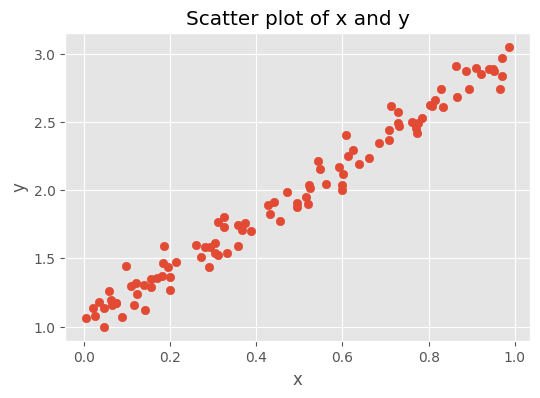

In [55]:
#data generation process
true_b = 1
true_w = 2
N = 100 #sample size 
# Data Generation
np.random.seed(42)
x = np.random.rand(N, 1)
epsilon = (.1 * np.random.randn(N, 1))
y = true_b + true_w * x + epsilon
# scatter plot for x and y 
plt.figure(figsize=(6, 4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x and y")
plt.show() 

initialized parameter values: [0.49671415] [-0.1382643]


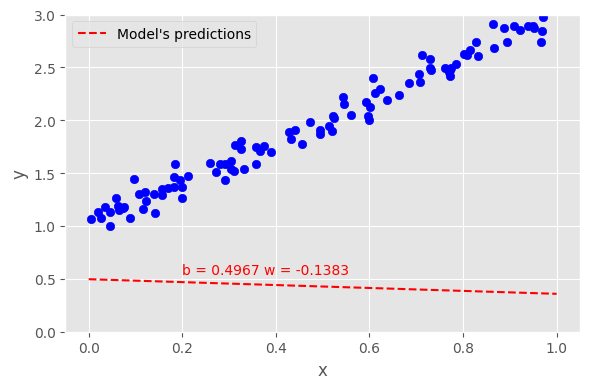

In [56]:
# Optimization using Gradient Descent
#step0 - initialization parameters 
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)
print('initialized parameter values:', b, w)
#step 1-compute & visualization of the model prediction 
yhat = b + w * x #compute the model prediction
x_range = np.linspace(0, 1, 101) #set the data range 
yhat_range = b + w * x_range #make the prediction
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_ylim([0, 3])
ax.scatter(x, y, color='blue') #dataset 
ax.plot(x_range, yhat_range, label='Model\'s predictions', c='red', linestyle='--')
ax.annotate('b = {:.4f} w = {:.4f}'.format(b[0], w[0]), xy=(.2, .55), c='red')
ax.legend(loc=0)
fig.tight_layout()

In [57]:
#Visualize the surface of MSE (the loss function)
#create a grid of b and w values
b_range = np.linspace(true_b - 3, true_b + 3, 101)
w_range = np.linspace(true_w - 3, true_w + 3, 101)
bs, ws = np.meshgrid(b_range, w_range) # meshgrid is a handy function that generates a grid of b and w
print('shape', bs.shape, ws.shape)
print('---------------------------------------')
print('bs:', bs)
print('---------------------------------------')
print('ws:', ws)

shape (101, 101) (101, 101)
---------------------------------------
bs: [[-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 ...
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]]
---------------------------------------
ws: [[-1.   -1.   -1.   ... -1.   -1.   -1.  ]
 [-0.94 -0.94 -0.94 ... -0.94 -0.94 -0.94]
 [-0.88 -0.88 -0.88 ... -0.88 -0.88 -0.88]
 ...
 [ 4.88  4.88  4.88 ...  4.88  4.88  4.88]
 [ 4.94  4.94  4.94 ...  4.94  4.94  4.94]
 [ 5.    5.    5.   ...  5.    5.    5.  ]]


In [58]:
# compute the MSE for each combination of b and w
all_predictions = np.apply_along_axis(
    func1d=lambda x: bs + ws * x, # linear prediction for each row of x
    axis=1, 
    arr=x
)
print("predictions", all_predictions.shape)
all_labels = y.reshape(-1, 1, 1)
print('transformed data shape:', all_labels.shape)
all_errors = (all_predictions - all_labels)
print('errors shape:', all_errors.shape)
all_losses = (all_errors ** 2).mean(axis=0) #mean over the sample
print('losses shape:', all_losses.shape)

predictions (100, 101, 101)
transformed data shape: (100, 1, 1)
errors shape: (100, 101, 101)
losses shape: (101, 101)


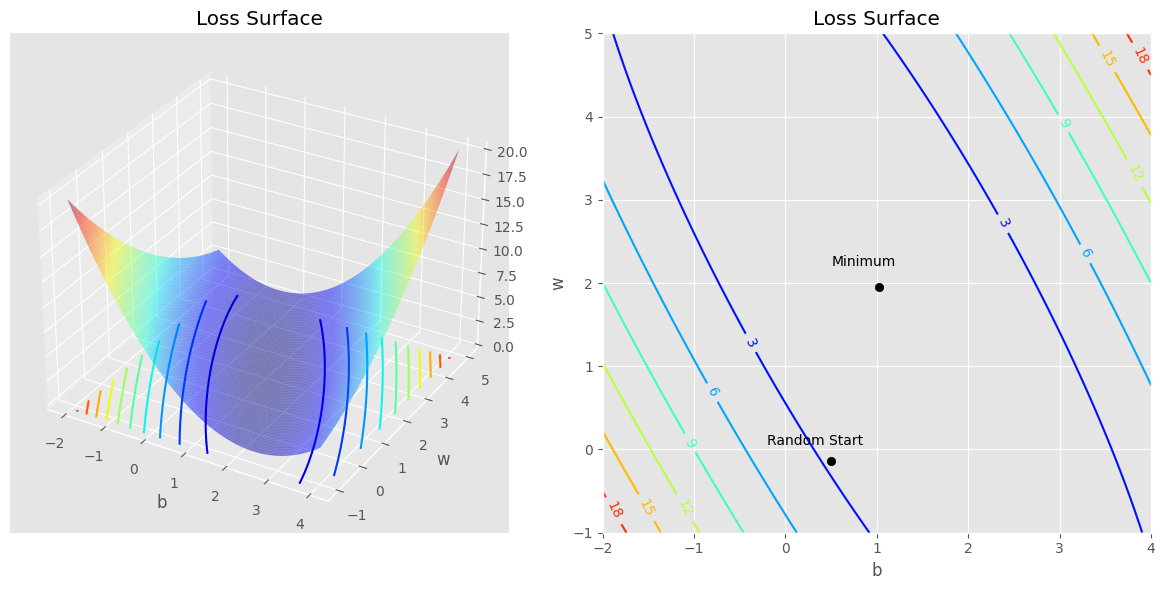

In [59]:
#plot the surface of MSE for b and w 
figure = plt.figure(figsize=(12, 6))
# 1st plot
ax1 = figure.add_subplot(1, 2, 1, projection='3d')
ax1.set_xlabel('b')
ax1.set_ylabel('w')
ax1.set_title('Loss Surface')
surf = ax1.plot_surface(bs, ws, all_losses, rstride=1, cstride=1, alpha=.5, cmap=plt.cm.jet, linewidth=0, antialiased=True)
ax1.contour(bs[0, :], ws[:, 0], all_losses, 10, offset=-1, cmap=plt.cm.jet)
ax1.view_init(30, -60)
# 2nd plot
regression = LinearRegression()
regression.fit(x, y)
b_minimum, w_minimum = regression.intercept_[0], regression.coef_[0][0] #regression method to get the minimum
ax2 = figure.add_subplot(1, 2, 2)
ax2.set_xlabel('b')
ax2.set_ylabel('w')
ax2.set_title('Loss Surface')
CS = ax2.contour(bs[0, :], ws[:, 0], all_losses, cmap=plt.cm.jet)
ax2.clabel(CS, inline=1, fontsize=10)
ax2.scatter(b_minimum, w_minimum, c='k') # Minimum
ax2.scatter(b, w, c='k') # Random start
ax2.annotate('Random Start', xy=(-.2, 0.05), c='k')
ax2.annotate('Minimum', xy=(.5, 2.2), c='k')   
figure.tight_layout()

Running Time: 0.0034 秒
Converged to (b,w) =(1.0216,1.9539)
Minimal Functional Value = 0.008065846759726845
Number of iterations = 130


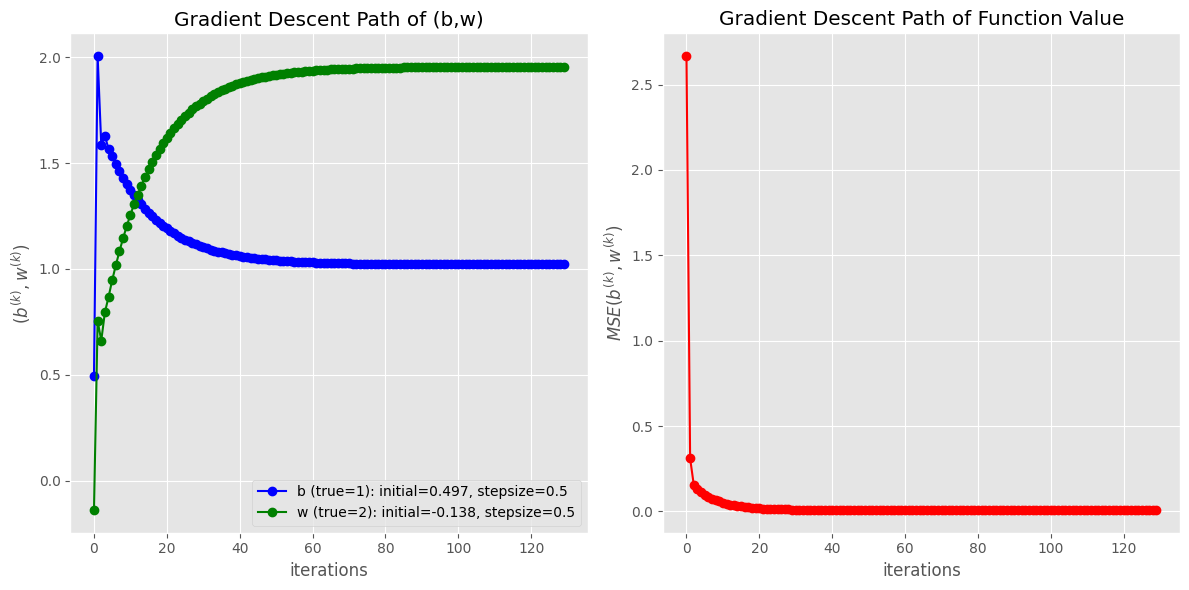

In [80]:
# Experiment 1: Random Start with Step Size = 0.2
# Step 2- Compute the gradient and visualization 
stepsize = 0.5 #learning rate 
b0 = b[0] #initial point 1
w0 = w[0] #initial point 1
tol = 1e-5 #tolerance for convergence
def mse_gradient(b, w):
    partial_b = (2 * (b + w * x - y)).mean()
    partial_w = (2 * (b + w * x - y) * x).mean()
    return partial_b, partial_w
partial2_b = 2
partial_bw = (2 * x).mean()
partial2_w = (2 * (x ** 2)).mean()
mse_hessian = np.array([[partial2_b, partial_bw], [partial_bw, partial2_w]])
# Step 3 - Iteration to solve the optimization problem
theta0 = np.array([b0, w0]) #initial point 1
funv_list = [np.mean((b0 + w0 * x - y) ** 2)]
theta_list = [theta0]
theta = theta0
start_time = time.time()  # 记录开始时间
while True:
    gradient = mse_gradient(theta[0], theta[1])
    theta_new = theta - stepsize * np.array(gradient)
    theta_list.append(theta_new)
    funv_list.append(np.mean((theta_new[0] + theta_new[1] * x - y) ** 2))
    if np.linalg.norm(theta_new - theta) < tol:
        break
    theta = theta_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to (b,w) =({:.4f},{:.4f})'.format(theta_new[0], theta_new[1]))
print('Minimal Functional Value =', funv_list[-1])
print('Number of iterations =', len(funv_list))
#plot the path of b and w and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot([theta[0] for theta in theta_list], 'o-', color='blue', label='b (true=1): initial={:.3g}, stepsize={:3g}'.format(b0, stepsize))
plt.plot([theta[1] for theta in theta_list], 'o-', color='green', label='w (true=2): initial={:.3g}, stepsize={:3g}'.format(w0, stepsize))
plt.xlabel('iterations')
plt.ylabel('$(b^{(k)},w^{(k)})$')
plt.legend()
plt.title('Gradient Descent Path of (b,w)')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$MSE(b^{(k)},w^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0025 秒
Converged to (b,w) =(1.0216,1.9539)
Minimal Functional Value = 0.008065846693800503
Number of iterations = 79


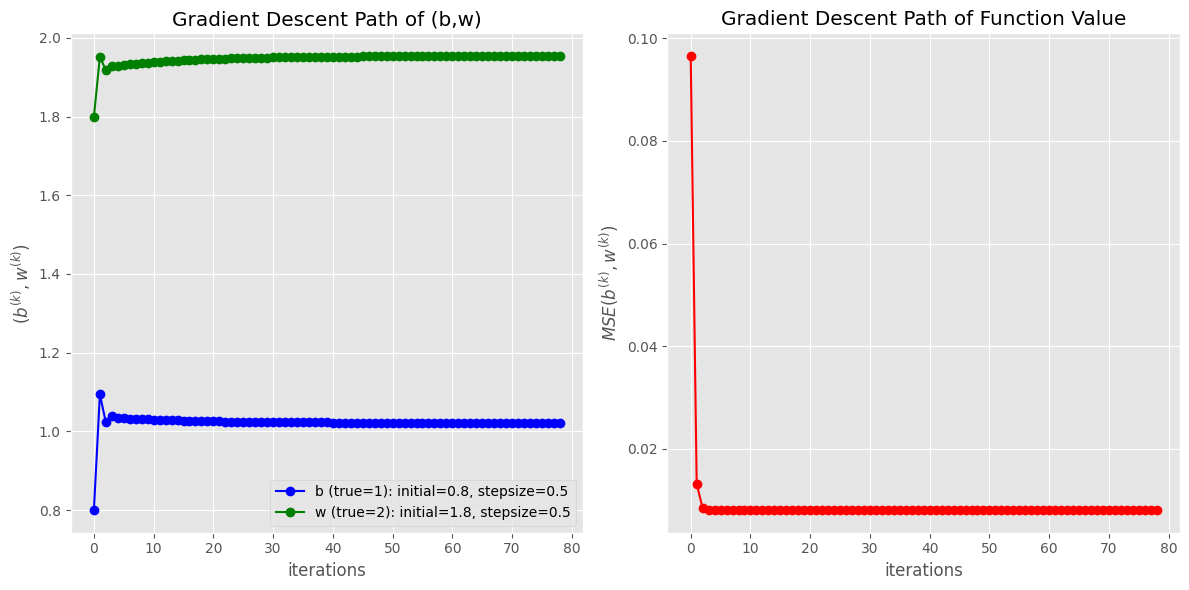

In [81]:
# Experiment 3: Start from Neighborhood of the Minimum with Step Size = 0.2
# Step 2- Compute the gradient and visualization 
b0 = 0.8 #initial point 2
w0 = 1.8 #initial point 2
# Step 3 - Iteration to solve the optimization problem
theta0 = np.array([b0, w0]) #initial point 1
funv_list = [np.mean((b0 + w0 * x - y) ** 2)]
theta_list = [theta0]
theta = theta0
start_time = time.time()  # 记录开始时间
while True:
    gradient = mse_gradient(theta[0], theta[1])
    theta_new = theta - stepsize * np.array(gradient)
    theta_list.append(theta_new)
    funv_list.append(np.mean((theta_new[0] + theta_new[1] * x - y) ** 2))
    if np.linalg.norm(theta_new - theta) < tol:
        break
    theta = theta_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to (b,w) =({:.4f},{:.4f})'.format(theta_new[0], theta_new[1]))
print('Minimal Functional Value =', funv_list[-1])
print('Number of iterations =', len(funv_list))
#plot the path of b and w and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot([theta[0] for theta in theta_list], 'o-', color='blue', label='b (true=1): initial={:.3g}, stepsize={:3g}'.format(b0, stepsize))
plt.plot([theta[1] for theta in theta_list], 'o-', color='green', label='w (true=2): initial={:.3g}, stepsize={:3g}'.format(w0, stepsize))
plt.xlabel('iterations')
plt.ylabel('$(b^{(k)},w^{(k)})$')
plt.legend()
plt.title('Gradient Descent Path of (b,w)')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$MSE(b^{(k)},w^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0004 秒
Converged to (b,w) =(1.0215,1.9540)
Minimal Functional Value = 0.008065845639670537
Number of iterations = 3


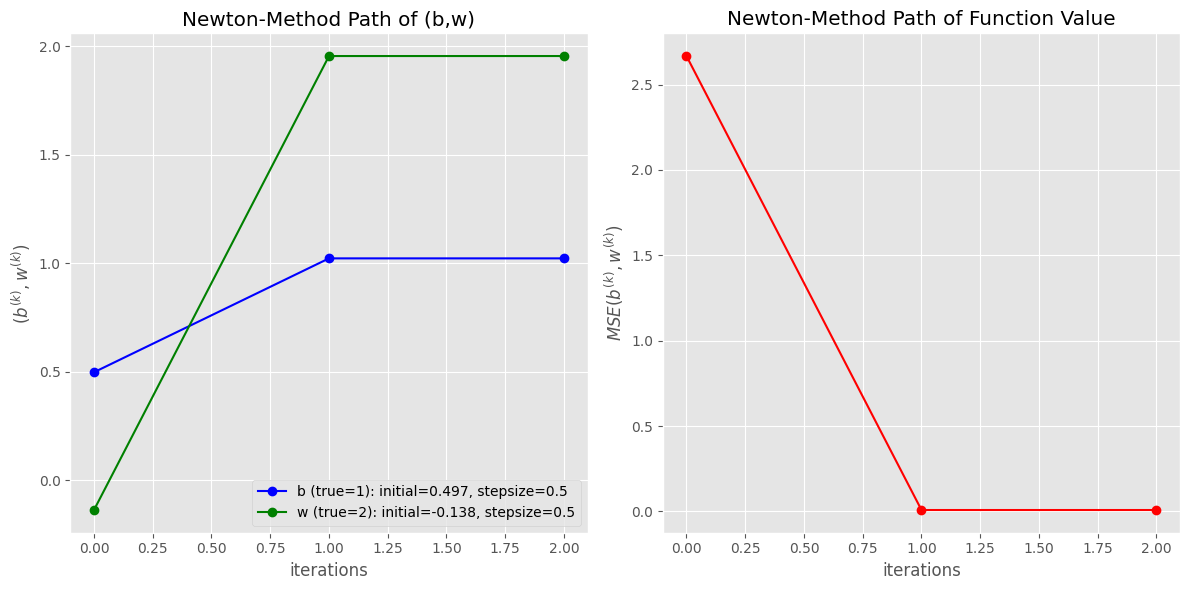

In [84]:
# Experiment 3: Newton Method: Random Start with Step Size = 0.2
# Step 2- Compute the gradient and visualization 
b0 = b[0] #initial point 1
w0 = w[0] #initial point 1
tol = 1e-5 #tolerance for convergence
# Step 3 - Iteration to solve the optimization problem
theta0 = np.array([b0, w0]) #initial point 1
funv_list = [np.mean((b0 + w0 * x - y) ** 2)]
theta_list = [theta0]
theta = theta0
start_time = time.time()  # 记录开始时间
while True:
    gradient = mse_gradient(theta[0], theta[1])
    theta_new = theta -  np.linalg.inv(mse_hessian) @ gradient #newton-method update 
    theta_list.append(theta_new)
    funv_list.append(np.mean((theta_new[0] + theta_new[1] * x - y) ** 2))
    if np.linalg.norm(theta_new - theta) < tol:
        break
    theta = theta_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to (b,w) =({:.4f},{:.4f})'.format(theta_new[0], theta_new[1]))
print('Minimal Functional Value =', funv_list[-1])
print('Number of iterations =', len(funv_list))
#plot the path of b and w and function value
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot([theta[0] for theta in theta_list], 'o-', color='blue', label='b (true=1): initial={:.3g}, stepsize={:3g}'.format(b0, stepsize))
plt.plot([theta[1] for theta in theta_list], 'o-', color='green', label='w (true=2): initial={:.3g}, stepsize={:3g}'.format(w0, stepsize))
plt.xlabel('iterations')
plt.ylabel('$(b^{(k)},w^{(k)})$')
plt.legend()
plt.title('Newton-Method Path of (b,w)')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$MSE(b^{(k)},w^{(k)})$')
plt.title('Newton-Method Path of Function Value')
plt.tight_layout()
plt.show()

## Optimization in Python: `Scipy.optimize`

Reference: [[Scipy Documentation]](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) [[Scipy Tutorial]](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg)

* `scipy.optimize.minimize` is a powerful function for optimization in Python. It provides various algorithms for minimizing a function, including  Newton's method and many others. 



In [134]:
# Solving the regression problem using Scipy.Optimize 
from scipy.optimize import minimize
def mse_loss(theta):
    b, w = theta
    return np.mean((b + w * x - y) ** 2)
def mse_gradient_fun(theta):
    b, w = theta
    partial_b = (2 * (b + w * x - y)).mean()
    partial_w = (2 * (b + w * x - y) * x).mean()
    return np.array([partial_b, partial_w])
def mse_hessian_fun(theta):
    return mse_hessian
# Step 1 - Initial guess
theta0 = np.array([b0, w0]) #initial point 1
# Step 2 - Call the optimizer using Newton's method
result = minimize(mse_loss, theta0, method='Newton-CG', jac=mse_gradient_fun, hess = mse_hessian_fun, options={'xtol': 1e-5, 'disp': True})
print('Converged to (b,w) =({:.4f},{:.4f})'.format(result.x[0], result.x[1]))
print('Regression Coefficients (b,w) =({:.4f},{:.4f})'.format(b_minimum, w_minimum))

Optimization terminated successfully.
         Current function value: 0.500000
         Iterations: 2
         Function evaluations: 4
         Gradient evaluations: 4
         Hessian evaluations: 2
Converged to (b,w) =(0.0000,-0.1383)
Regression Coefficients (b,w) =(1.0215,1.9540)


### Numerical Differentiation and Integration
---

* **forward difference** : $\large f'(x_j) \approx \frac{f(x_{j+1}) - f(x_j)}{x_{j+1}-x_j}$

* **backward difference**: $\large f'(x_j)  \approx  \frac{f(x_j) - f(x_{j-1})}{x_j - x_{j-1}}$

* **central difference**:$\large f'(x_j)  \approx  \frac{f(x_{j+1}) - f(x_{j-1})}{x_{j+1} - x_{j-1}}$


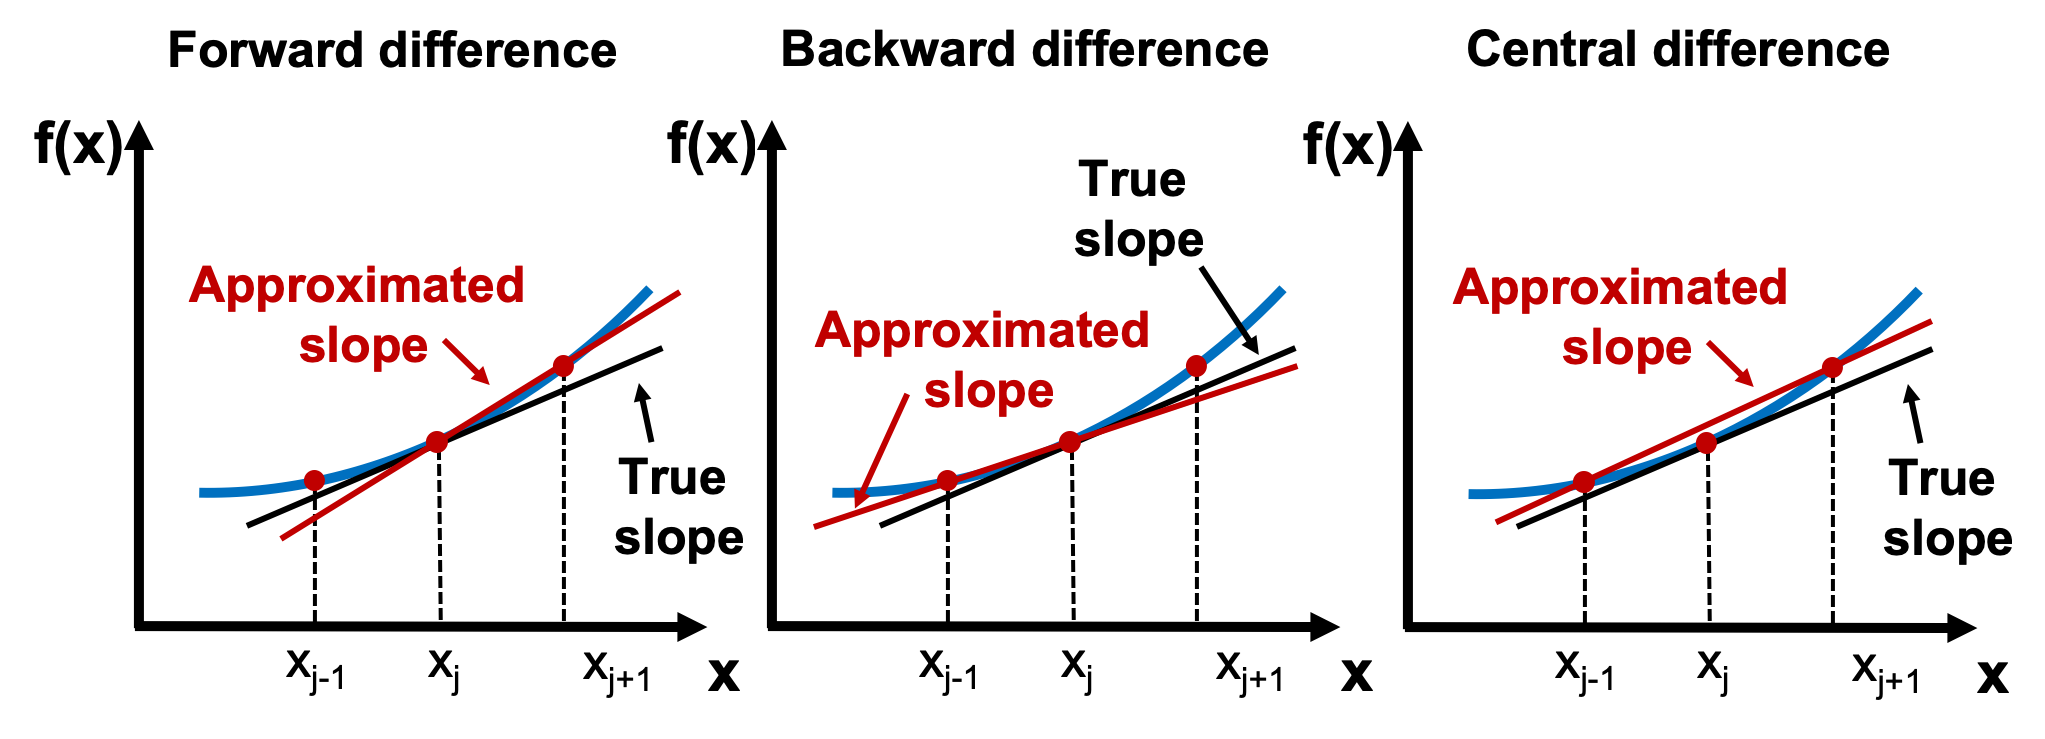

### Taylor Series Expansion and Finite Difference Approximation 
---
* For differentiable function $f(x)$, the **Taylor series expansion** around point $x_j$ is $$ \small
f(x) = \frac{f(x_j)(x - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x - x_j)^1}{1!} + \frac{f''(x_j)(x - x_j)^2}{2!} + \frac{f'''(x_j)(x - x_j)^3}{3!} + \cdots.$$

* For evenly spaced points, $x_{j+1} = x_j + h$, fix $x = x_{j+1}$ to get 
\begin{aligned}
\small
f(x_{j+1}) =&  \frac{f(x_j)(x_{j+1} - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x_{j+1}- x_j)^1}{1!} + \frac{f''(x_j)(x_{j+1} - x_j)^2}{2!} + \cdots. \\
\Rightarrow   f^{\prime}(x_j) =    & \frac{f(x_{j+1}) - f(x_j)}{h} + \underbrace{\left(-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots\right)}_{=h\cdot[\alpha + \epsilon(h)]= O(h)}.
\end{aligned}
   * $O(h)$ describes the **accuracy**: **Forward difference** approximation is $O(h)$
> **Accuracy Comparison**: Assume $q < p$, an $O(h^p)$-approximation of a value gets closer to the true value faster than $O(h^q)$-approximation.


* Computing the Taylor series around $a = x_j$ at $x = x_{j-1}$, solving for $f^{\prime}(x_j)$ to get the **backward difference** formula
$$
f^{\prime}(x_j) = \frac{f(x_j) - f(x_{j-1})}{h} +O(h)
$$

* Computing the Taylor series around $a = x_j$ at both $x_{j+1}$ and $x_{j-1}$ yields the **central difference** formula:
\begin{aligned}
f(x_{j+1}) &= f(x_j) + f^{\prime}(x_j)h + \frac{1}{2}f''(x_j)h^2 + \frac{1}{6}f'''(x_j)h^3 + \cdots \\
f(x_{j-1}) &= f(x_j) - f^{\prime}(x_j)h + \frac{1}{2}f''(x_j)h^2 - \frac{1}{6}f'''(x_j)h^3 + \cdots. \\
\Rightarrow f^{\prime}(x_j) &= \frac{f(x_{j+1}) - f(x_{j-1})}{2h} + O(h^2)
\end{aligned}
    * The **central difference formula** is $O(h^2)$, but **it requires the same amount of computational effort as the forward and backward difference formulas**! 

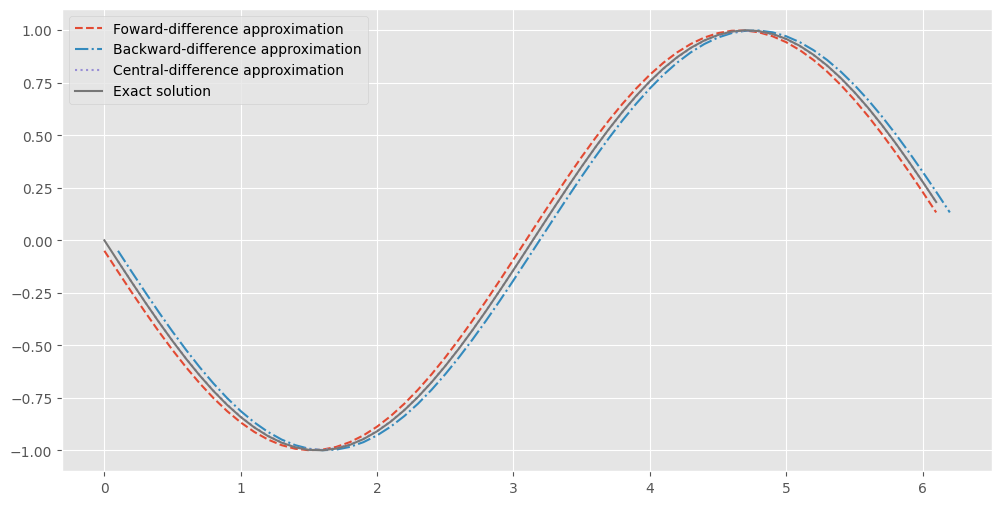

Maximum Error: ForwardDiff=0.0500, BackwardDiff=0.0500, CentralDiff=0.0017


In [135]:
# Example: Numerical Differentiation 
h = 0.1 # step size
x = np.arange(0, 2*np.pi, h) # define grid
y = np.cos(x)  # compute function
forward_diff = np.diff(y)/h # compute vector of forward differences
backward_diff = (y[1:]-y[:-1])/h # compute vector of backward differences
central_diff = (y[2:]-y[:-2])/(2*h) # compute vector of central differences
x_fdiff = x[:-1] # compute corresponding grid
x_bdiff = x[1:] # compute corresponding grid
x_cdiff = x[1:-1] # compute corresponding grid
exact_solution = -np.sin(x_fdiff) # compute exact solution
# Plot to compare among solutions
plt.figure(figsize = (12, 6))
plt.plot(x_fdiff, forward_diff, '--', label = 'Foward-difference approximation')
plt.plot(x_bdiff, backward_diff, '-.',label = 'Backward-difference approximation')
plt.plot(x_cdiff, central_diff, ':', label = 'Central-difference approximation')
plt.plot(x_fdiff, exact_solution, label = 'Exact solution')
plt.legend()
plt.show()
# Compute maximum errors 
print('Maximum Error: ForwardDiff={:.4f}, BackwardDiff={:.4f}, CentralDiff={:.4f}'.format(
    np.max(np.abs(forward_diff - exact_solution)), 
    np.max(np.abs(backward_diff - exact_solution)), 
    np.max(np.abs(central_diff - exact_solution[1:]))))


We can compute the numerical derivative using different $h$'s and plot the maximum error to show the **accuracy** of the different methods. 

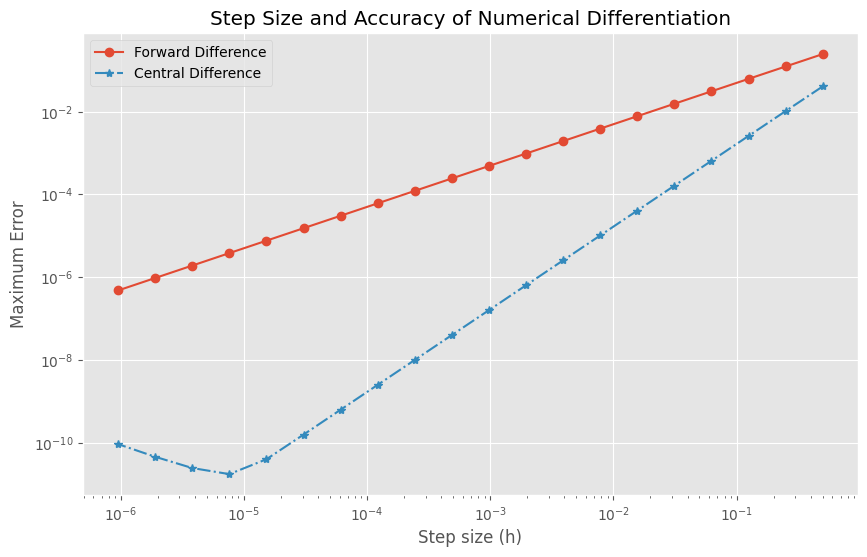

In [136]:
# Compare the Accuracy of Different Methods 
h = 1
iterations = 20 
step_size = [] 
# list to store max error for each step size
max_error = [] 
for i in range(iterations):
    h /= 2 
    step_size.append(h) 
    x = np.arange(0, 2 * np.pi, h) 
    y = np.cos(x) 
    forward_diff = np.diff(y)/h # compute vector of forward differences
    central_diff = (y[2:]-y[:-2])/(2*h) # compute vector of central differences
    x_fdiff = x[:-1] # compute corresponding grid
    x_cdiff = x[1:-1] # compute corresponding grid
    exact_solution = -np.sin(x_fdiff)  # compute exact solution
    max_error.append([max(abs(exact_solution - forward_diff)), max(abs(exact_solution[1:] - central_diff))])
# produce log-log plot of max error versus step size
plt.figure(figsize = (10, 6))
plt.loglog(step_size, [r[0] for r in max_error], 'o-', label='Forward Difference') 
plt.loglog(step_size, [r[1] for r in max_error], '*-.', label='Central Difference')  
plt.xlabel('Step size (h)')
plt.ylabel('Maximum Error')
plt.legend()
plt.title('Step Size and Accuracy of Numerical Differentiation')
plt.show()

### Numerical Differentiation in Python: `Autograd`

[`Autograd`](https://github.com/HIPS/autograd/tree/master) is a Python library that can automatically differentiate native Python and NumPy functions. It is particularly useful for machine learning and optimization tasks where gradients are needed.

* Will be of more use for training machine learning models, but we can also use it for numerical differentiation.

* **Installation**: `pip install autograd`


/Users/happyhome/Library/Mobile Documents/com~apple~CloudDocs/Research/Causal Study/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


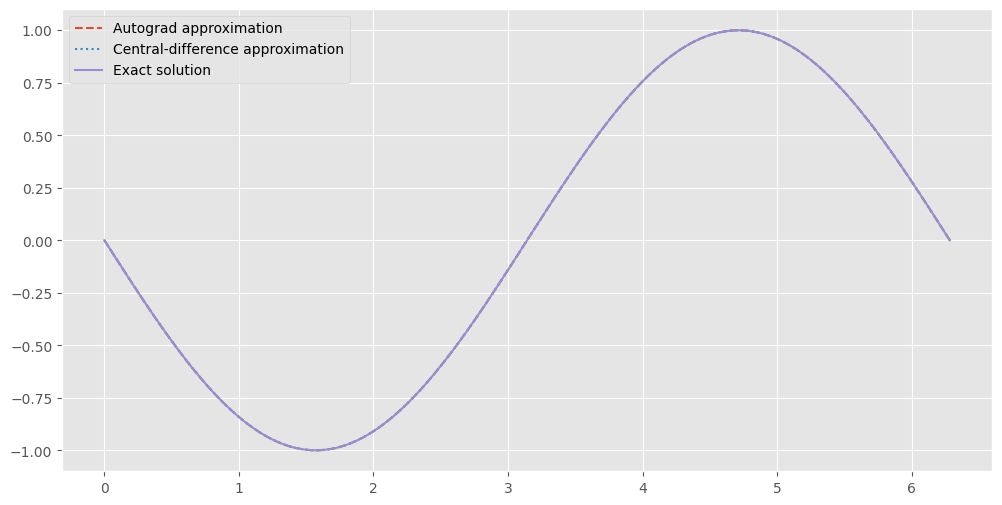

Maximum Error: AutoDiff=0.00000, CentralDiff=0.00000


In [137]:
import autograd.numpy as au
from autograd import elementwise_grad

def f(x): # Objective function
    return au.cos(x) 
grad_f = elementwise_grad(f) # derivative for each element
# Plot to compare among solutions
plt.figure(figsize = (12, 6))
plt.plot(x_cdiff, grad_f(x_cdiff), '--', label = 'Autograd approximation')
plt.plot(x_cdiff, central_diff, ':', label = 'Central-difference approximation')
plt.plot(x_cdiff, exact_solution[1:], label = 'Exact solution')
plt.legend()
plt.show()
# Compute maximum errors 
print('Maximum Error: AutoDiff={:.5f}, CentralDiff={:.5f}'.format(
    np.max(np.abs(grad_f(x_cdiff) - exact_solution[1:])), 
    np.max(np.abs(central_diff - exact_solution[1:]))))

### Numerical Integration
---

* **Riemann Integral (黎曼积分)**, let $h = \frac{b-a}{n}$ be the width of each subinterval: $$ \int_a^b f(x) dx = \sum_{i = 0}^{n-1} hf(x_i)+O(h) \text{ (Left end point)}$$ $$\int_a^b f(x) dx = \sum_{i = 1}^{n} hf(x_i)+O(h) \text{ (Right end point)}$$ $$\int_a^b f(x)dx = \sum_{i = 0}^{n-1} hf(\frac{x_{i+1} + x_i}{2})+O(h^3)  \text{ (Midpoint rule)}$$


* Since the Midpoint Rule requires the same number of calculations as the Riemann Integral, we essentially get an extra order of accuracy for free!

### Trapezoidal Rule 

* **Trapezoidal Rule**: Approximate the area under the curve using trapezoids.
$$
\int_a^b f(x) dx = \frac{h}{2} \left[f(a) + 2\sum_{i=1}^{n-1} f(x_i) + f(b)\right] + O(h^2)
$$

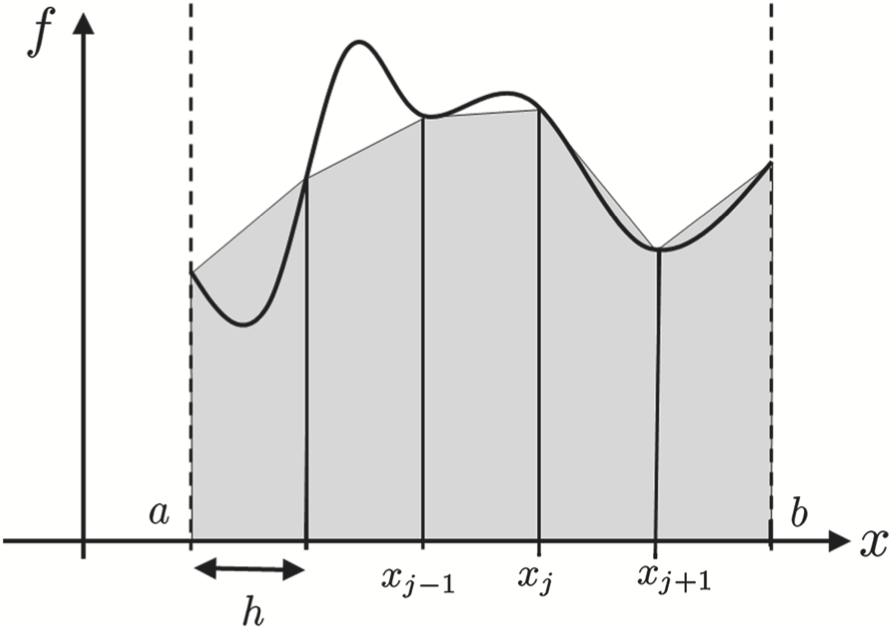

### Simpson's Rule

* **Simpson's Rule**: A more accurate method that uses parabolic segments to approximate the area under the curve. 
$$
\int_a^b f(x) dx = \sum_{i=1}^{n-1} \frac{h}{3}[f(x_{i-1})+4f(x_i)+f(x_{i+1})] +O(h^4)$$
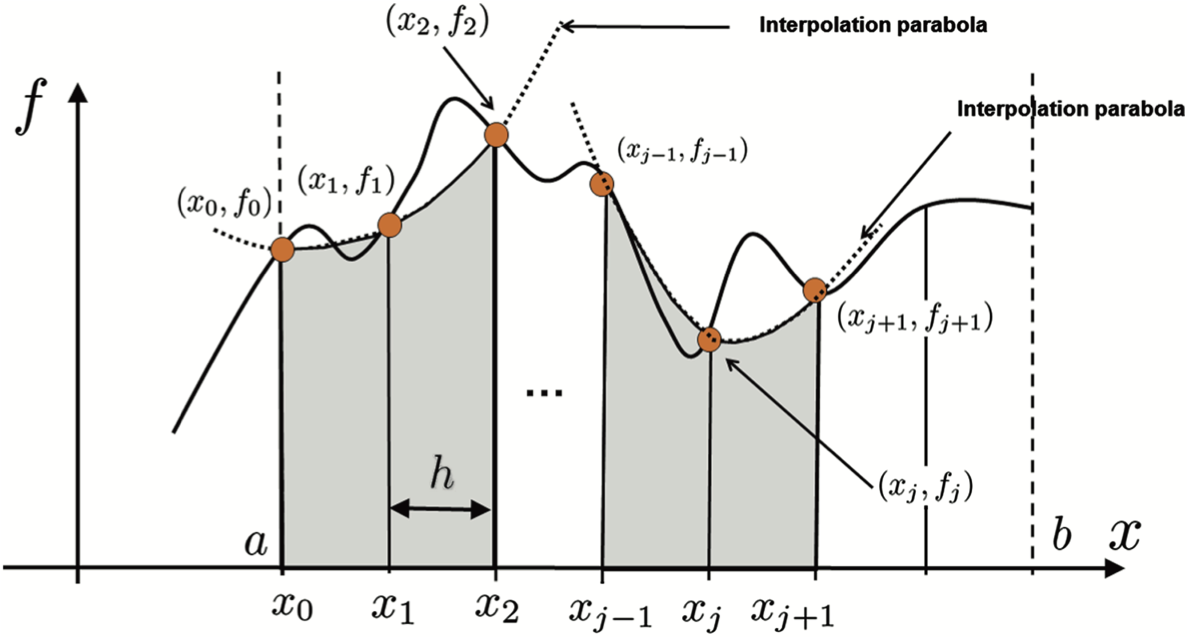

In [149]:
#Different  Methods of Integration: for f(x)=sin(x) on [0, pi]
a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)
# Start Point
I_riemannL = h * sum(f[:-1])
err_riemannL = 2 - I_riemannL
# End Point
I_riemannR = h * sum(f[1::])
err_riemannR = 2 - I_riemannR
# Mid Point 
I_mid = h * sum(np.sin((x[:-1] + x[1:])/2))
err_mid = 2 - I_mid
# Trapezoidal Rule
I_trap = (h/2)*(f[0] + 2 * sum(f[1:n-1]) + f[n-1])
err_trap = 2 - I_trap
# Simpson's Rule
I_simp = (h/3) * (f[0] + 2*sum(f[:n-2:2]) + 4*sum(f[1:n-1:2]) + f[n-1])
err_simp = 2 - I_simp
print('Start_point, End_point, Mid_point, Trape, Simpson \n ({:.4f}, {:.4f}, {:.4f}, {:.4f}, {:.4f})'.format(I_riemannL, I_riemannR, I_mid, I_trap, I_simp))
print("Start_Error, End_Error, Mid_Error, Trape_Error, Simpson_Error \n ({:.4f}, {:.4f}, {:.4f}, {:4f}, {:4f})".format(err_riemannL, err_riemannR, err_mid, err_trap, err_simp))

Start_point, End_point, Mid_point, Trape, Simpson 
 (1.9835, 1.9835, 2.0082, 1.9835, 2.0001)
Start_Error, End_Error, Mid_Error, Trape_Error, Simpson_Error 
 (0.0165, 0.0165, -0.0082, 0.016476, -0.000110)


### Economic Application II: BLP Method for Demand Estimation
---

* The demand estimation method (Berry, Levisohn, and Pakes, 1995)  is a model method for estimating demand in differentiated products markets. See my previous [BLP lecture notes](https://gitee.com/zhiyuanryanchen/econ-research-methods/tree/master/2020Fall/Lecture7/13-BLP) for more details. 

* [`PyBLP`](https://pyblp.readthedocs.io/en/stable/introduction.html) is a Python package for implementing the BLP method. You should check it out!

* During the estimation procedure, we need to use numerical integration to compute the market shares: $$ s_{jt} = \int_{A_{jt}} dP_\varepsilon(\varepsilon) dP_\nu(\nu) dP_D(D) \tag{3}$$
  * where $ A_{jt}(x_{\cdot t}, p_{\cdot t}, \delta_{\cdot t}; \theta_2) = \left\{(D_i, \nu_i, \varepsilon_{i, \cdot, t}) : \forall \ell \in J, u_{ijt}\geq u_{i \ell t} \right\} $ represents the set of consumers. 

## Raw Fixed-Point-Based Iterations
---

### Fixed Points (不动点)

> **Fixed Point**: A point $ x^* \in X $ is a *fixed point* of a function $ T: X \to X $ if: $$\Large T(x^*) = x^*$$

- **Intuition**: Applying the function $ T $ doesn't change the value.

- **Examples**:
  - $ T(x) = \cos(x) $ has a fixed point near $ x = 0.739 $
  - In economics: **fixed point** of a best response function corresponds to a **Nash equilibrium**.



### Contraction Mapping

> **Definition**: A function $ T: X \to X $ is a *contraction* on a **metric space** $ (X, d) $ if:$$\large
  d(T(x), T(y)) \leq \beta \cdot d(x, y), \quad \text{for all } x, y \in X, \text{ with } 0 < \beta < 1$$


- The constant $\beta$ is called the **Lipschitz constant**

- **Key Property**: Contractions "shrink" distances between points.


- **Examples**:
  - $T(x) = 0.5x \text{ on } \mathbb{R}$ is a contraction with contraction constant $ \beta = 0.5 $.
  
  - $T(x) = x^{0.2}$ on $[0, 1]$ is a contraction with some contraction constant 

###  Banach Fixed Point Theorem
---

> **Banach Fixed Point Theorem**: If $ T $ is a contraction on a complete metric space $ X $,then:
>    1. There exists a **unique fixed point**  $ x^* \in X $
>    2. The **iterative method** $ x_{n+1} = T(x_n) $ **converges** to $ x^* $ for any initial point $ x_0 \in X $

- **Intuition**: A **contraction mapping** "pulls" all points closer together. That is, if two points are far apart, applying the function brings them closer, and the amount they’re brought closer is uniformly bounded by a **contraction factor**.

- **Convergence Rate**: Linear convergence with rate $ \beta $.
  
- **Relieve the curse of dimensionality** as the matrix-based operations are fast!


### Derivative-Based Condition for Contraction 
---

> **Jacobian Norm Condition**: Let $T: \mathbb{R}^n \to \mathbb{R}^n$ be a continuously differentiable function. If the **Lipschitz constant** of $T$ is less than 1, i.e., $$ \|\nabla T(x)\| < 1$$  for all $x \in \mathbb{R}^n$, where $\|\cdot \|$ is an **operator norm (算子范数)**, then $T$ is a contraction mapping. 

> **Operator Norm (算子范数)**: For linear operators $A\in \mathbb{R}^{n\times n}$, and let $\|\cdot\|$ be a norm on $\mathbb{R}^n$. Then the operator norm, induced by that norm, is defined as: $$ \|A\|  = \sup_{\|x\|=1} \|Ax\|$$

* 它度量了算子$A$把单位向量最多能“放大”多少

* To ensure contraction mapping, we need the operator norm to be less than 1.

#### Examples of Operator Norms(算子范数)
---


* **Example 1**: For $A = \alpha \in \mathbb{R}$, the operator norm is $\|A\| = |\alpha|$.
  
* **Example 2**: For $A = \begin{bmatrix} 2 & 0 \\ 0 & 0.5 \end{bmatrix}$, the operator norm is $\|A\| = \max\{2, 0.5\}=2$ ($\ell_2$-norm (欧几里得范数)).
$$\sup_{x_1^2+x_2^2=1} \sqrt{(2x_1)^2 + (0.5x_2)^2} $$

* **Example 3**: For $A = \begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix}$
  
  * the operator norm is $\|A\| _{\infty} = \max \{1+2, 0+1\} = 3$ ($\ell_{\infty}$-norm (无穷范数), 最大行和).
  
  *  the operator norm is $\|A\| _{1} = \max \{1+0, 2+1\} = 3$ ($\ell_{1}$-norm (1范数)，最大列和). 
  
  * the operator norm is $\|A\| _{2} \approx 2.618$ ($\ell_{2}$-norm (2范数)).

### Fixed-Point Iteration Algorithm
---
- **Initialization**: Choose $ x_0 \in X $
- **Iteration**: Update using:
  $
  x_{n+1} = T(x_n)
  $

- **Stopping Criterion**: Stop when:
  $
  \|x_{n+1} - x_n\| < \epsilon
  $

- **Pseudocode in Python**:
```python
x = x0
for i in range(max_iter):
    x_new = T(x)
    if norm(x_new - x) < tol:
        break
    x = x_new


### Revisit Application I: the Solow Growth Model
---
#### Convergence of Direct Iteration
- Using the [**monotone convergence theorem**](https://en.wikipedia.org/wiki/Monotone_convergence_theorem), we can show that the sequence $\{k_t\}_{t=0}^{\infty}$ converges $k^*$

-  Also, $g(k) = sAk^\alpha + (1-\delta)k$ is a contraction mapping if the derivative $g'(k)$ satisfies $\|g'(k)\| < 1$ for all $k > 0$, which is satisfied in the neighborhood of the steady state $k^*$.

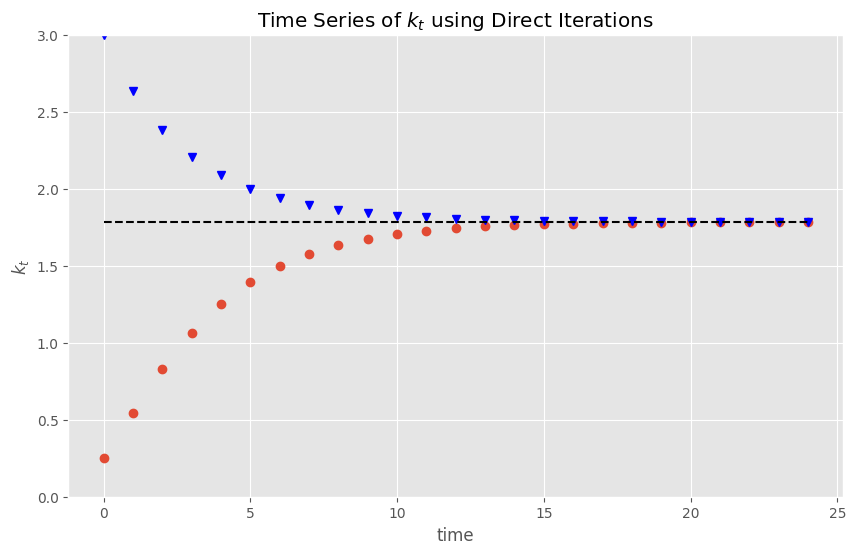

In [319]:
#Solving the Steady-state using direct iterations
def compute_iterates(k_0, f, params, n=25):
    "Compute time series of length n generated by arbitrary function f."
    k = k_0
    k_iterates = []
    for t in range(n):
        k_iterates.append(k)
        k = f(k, params)
    return k_iterates
params = create_solow_params()
k_0 = 0.25
k_series = compute_iterates(k_0, g, params)
k_0 = 3.0
k_series1 = compute_iterates(k_0, g, params)
k_star = exact_fixed_point(params)
fig, ax = plt.subplots()
ax.plot(k_series, 'o')
ax.plot(k_series1, 'v', color='blue')
ax.plot([k_star] * len(k_series), 'k--')
ax.set_xlabel("time")
ax.set_ylabel("$k_t$")
ax.set_title("Time Series of $k_t$ using Direct Iterations")
ax.set_ylim(0, 3)
plt.show()

### Application III: Market Share Iteration in BLP Demand Estimation 
---

* In the random coefficient demand model, the market share equation is given by: 
$$
s(x, p, \delta, P_{ns}; \theta_2) = \sum_{i = 1}^S w_i
\frac{\exp \left\{ \delta_{jt} + [-p_{jt}, x_{jt}](\Pi D_i + \Sigma v_i) \right\} }
{ 1 + \sum_{\ell \in J_t} \exp \left\{ \delta_{\ell t} + [-p_{\ell t}, x_{\ell t}](\Pi D_i + \Sigma v_i) \right\}} 
$$

* We need to find mean utility $\delta$ to solve the nonlinear equation:
  $$ s(x, p, \delta; \theta_2)-S = 0 $$

* BLP proves that this is a contraction mapping, and we can use fixed-point iteration to find the solution:
 $$ \delta_{\cdot t}^{h+1} = \delta_{\cdot t}^{h} + \log S_{\cdot t} - \log
s_{\cdot t}(x_{\cdot t}, p_{\cdot t}, \delta_{\cdot t}^h; \theta_2) $$ 

### Application IV: Gravity Model Estimation
---
* The classical reduced-form gravity model (in logs) is given by: 
 \begin{equation}
    x_{ij} = \alpha + \alpha_1  y_i + \alpha_2 y_j + \theta  d_{ij} + \gamma \delta_{ij} + \epsilon_{ij} 
\end{equation}
* The Armington trade model is a canonical model for modern trade theory, see my previous [lecture notes](https://gitee.com/zhiyuanryanchen/econ-research-methods/tree/master/2020Fall/Lecture6/12-Gravity) for more details. 

* With a general equilibrium condition, we can obtain the logged gravity equation: 
  \begin{aligned}
\ln x_{ij} =& k + \ln y_i +  \ln y_j + (1 - \sigma) \rho \ln d_{ij} + (1 - \sigma) \ln b_{ij}  \\
   &- (1 - \sigma) \ln P_i - (1-\sigma) P_j
  \end{aligned}
  * $P_i$ and $P_j$ are the price indices for country $i$ and $j$ satisfying $$P_j^{1-\sigma} = \sum_i P_i^{\sigma - 1} \theta_i t_{ij}^{1-\sigma} $$ where $\theta_i = y_i / y^{World}$ is the income share of country $i$ in the world, and $y_i = \sum_j x_{ij}$ is the total income of country $i$. $t_{ij}\propto d_{ij}^\rho$ the trade cost between country $i$ and $j$. 


#### Solving the System of Prices 

* [Alvarez and Lucas (2007)](https://epge.fgv.br/users/rubens/wp-content/uploads/2009/12/lucas-alvarez.pdf) show that the system of prices is a **contraction mapping** and we can use **fixed-point iteration** to solve the system of prices.

* We illustrate the algorithm using an example with 10 countries in `Python` 

In [317]:
### Fixed-Point Iteration for Price Index in Gravity Model 
#parameterization
n = 10 #number of countries 
GravityParams = namedtuple("GravityParams", ('σ', 'Theta', 'T'))
np.random.seed(42)
rand_y = np.random.rand(n, 1)
Theta0 =1/np.exp(rand_y).sum() * np.exp(rand_y)
T0 = np.random.uniform(2, 4, size=(n,n))
#replace the diagonal with 1
T0[np.diag_indices(n)] = 1  # Set diagonal elements to 1
def create_gravity_params(σ=2, Theta=Theta0, T=T0):
    return GravityParams(σ=σ, Theta=Theta, T=T0)
def price_iteration(params, tol = 1e-5, max_iter=1000):
    σ, Theta, T = params
    n = len(Theta)
    P = np.ones(n)  # Initial guess for price index, 1-by-n
    P = P.reshape((n,1))
    Plist = [P.copy()]  # Store the price index at each iteration
    for i in range(max_iter):
        P_new = ((T**(1-σ)) @ (Theta * P**(σ - 1)))**(1/(1-σ))
        Plist.append(P_new.copy())
        if np.linalg.norm(P_new - P) < tol:
            print("Converged to price index after {} iterations.".format(len(Plist)))   
            return P_new, Plist
        P = 0.5*P_new + 0.5*P 
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return P, Plist

In [318]:
#use iteration to solve the price index
params = create_gravity_params()
Pindex, Plist = price_iteration(params)
print(Pindex)

Converged to price index after 14 iterations.
[[1.60930261]
 [1.44639883]
 [1.53684876]
 [1.47409484]
 [1.6828524 ]
 [1.64322691]
 [1.53732657]
 [1.51458496]
 [1.57367854]
 [1.52366881]]


#### Application V: Solving Input Allocations of Multi-Product Firms 
---
* `Chen and Liao`(2024) show that the input allocation problem of multi-product production function boils down to the following non-linear system of equations:
$$\small
X_{ijt}^*	=\frac{P_{ijt}Q_{ijt}\gamma_{j}^{x}(\mathbf{x}_{ijt}^*)}{\sum_{j'}P_{ij't}Q_{ij't}\gamma_{j'}^{x}(\mathbf{x}_{ij't}^*)}\bar{X}_{it}\quad \text{for } X \in \{K, L, M\}
$$
 where $\gamma_j^x(\mathbf{x}_{ijt}^*)$ is the output elasticity of input $x$ for product $j$ at the optimal input allocation $\mathbf{x}_{ijt}^*$. 

* For CES production function $$Q(K_{ijt},L_{ijt},M_{ijt};\bm{\beta}_j)=e^{\omega_{ijt}}\left( \beta_{j}^k K_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}+ \beta_{j}^l L_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}+ \beta_{j}^m M_{ijt}^{\frac{\kappa_j-1}{\kappa_j}} \right)^{\frac{\nu_j \kappa_j}{\kappa_j-1}},\quad  \text{for } j\in\mathcal{J}.$$ where $\kappa_j>0$ is the elasticity of substitution, $\nu_j>0$ is the scale parameter, and $\beta_j^k+ \beta_j^l + \beta_j^m=1$ are the input shares for product $j$. 

### Computational Problem and Contraction Mapping-based Iteration 
---

* The problem is to find the optimal input allocation $\mathbf{x}_{ijt}^*$ for each product $j$ for firm $i$ at time $t$. 
  * For a single firm, the problem is naively a system of 3 equations in 3 unknowns, i.e., $K_{ijt}^*, L_{ijt}^*, M_{ijt}^*$. 
  
  * For 3 products, 1000 firms, and 5 time periods, we have $3*3*1000*5=45000$ equations to solve. This has to be solved multiple times in the estimation of production function parameters to minimize the objective function. 
  
* Define a mapping $\mathbf{T}: \mathbb{R}^{3JN}\rightarrow \mathbb{R}^{3JN}$ such that: 
  \begin{aligned}
  \mathbf{T} =& [\mathbf{T}_1, \mathbf{T}_2, \cdots, \mathbf{T}_N]_{3JN\times 1}^\top \\
   \mathbf{T}_i =& [\{T_{i}(K,j)\}_{j=1}^J, \{T_{i}(L,j)\}_{j=1}^J, \{T_{i}(M,j)\}_{j=1}^J]_{3J\times 1}^\top \\
   \mathbf{T}_i(X, j) = &\log\left(\frac{ P_{ij}Q_{ij}\gamma_j^x(\mathbf{x}_{ij})}{\sum_{j'}P_{ij'}Q_{ij'}{\gamma}_j^x (\mathbf{x}_{ij'})}\bar{X}_{i}\right),\quad \text{for } X\in \{K, L, M\} 
  \end{aligned}
 We can derive the output elasticity of input $x$ as follows:
  $$\small \gamma_{j}^{x}(\mathbf{x}_{ijt}) = \frac{v_j\beta_j^x X_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}}{\beta_{j}^k K_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}+\beta_j^l L_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}+ \beta_j^m M_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}}, \quad \text{for } X\in \{ K, L, M\}.	$$

* It can be shown that when $\frac{|\kappa_j-1|}{\kappa_j} < 1$, the mapping $\mathbf{T}$ is a **contraction**. 

In [536]:
#Solving input allocations 
from scipy.stats import pareto 
mp_params = namedtuple("mp_params",('βl_1','βl_2', 'βk_1', 'βk_2', 'κ_1', 'κ_2', 'v_1', 'v_2'))
def mp_input_params(βl_1=0.2, βl_2=0.2, βk_1=0.3, βk_2=0.2, κ_1=0.9, κ_2=0.8, v_1=1, v_2=1):
    return mp_params(βl_1=βl_1, βl_2=βl_2, βk_1=βk_1, βk_2=βk_2, κ_1=κ_1, κ_2=κ_2, v_1=v_1, v_2=v_2)
def mp_data(params, n=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    np.random.seed(42)  # Set random seed for reproducibility
    R = (pareto.rvs(3., scale =1., size=(n, 2)) + 1) #revenues for 2 products
    # shift the second product's revenue to ensure it's higher than the first
    R[:, 1] += 2.0
    K = np.exp(np.random.normal(1, 2, (n, 1)))  # firm-level Capital, Labor, and Materials
    L = np.exp(np.random.normal(0, 2, (n, 1)))  # firm-level Labor
    M = np.exp(np.random.normal(2, 5, (n, 1)))  # firm-level Materials
    data = [R, K, L, M]
    return data

def mp_input_allocation(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # Material allocation parameter
    βm_2 = 1.0 - βl_2 - βk_2  # Material allocation parameter
    R, K, L, M = data  # Unpack the data
    Lopt= [0.5*np.log(L), 0.5*np.log(L)] # Initial guess for Labor allocation
    Kopt = [0.5*np.log(K), 0.5*np.log(K)] # Initial guess for Capital allocation
    Mopt = [0.5*np.log(M), 0.5*np.log(M)]  # Initial guess for Materials allocation
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    
    for i in range(max_iter):
        #compute output elasticities 
        γ_k = [v_1*βk_1* (np.exp(Kopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)), 
                v_2*βk_2* (np.exp(Kopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (np.exp(Lopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)),
                v_2*βl_2* (np.exp(Lopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # compute the input allocations 
        Kopt_new = np.log([K*R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), K*R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])])
        Lopt_new = np.log([L*R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), L*R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])])
        Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        
        if np.linalg.norm(Lopt_new - Lopt) < tol and np.linalg.norm(Kopt_new - Kopt) < tol and np.linalg.norm(Mopt_new-Mopt) < tol:
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        Lopt = Lopt_new
        Kopt = Kopt_new
        Mopt = Mopt_new
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt, Kopt, Mopt, Llist, Klist, Mlist

In [422]:
# iteration to solve the input allocation problem
params = mp_input_params()
data = mp_data(params, n =10_000)
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation(params, data)

Converged to input allocations after 12 iterations.
CPU times: user 43.4 ms, sys: 8.58 ms, total: 52 ms
Wall time: 56.6 ms


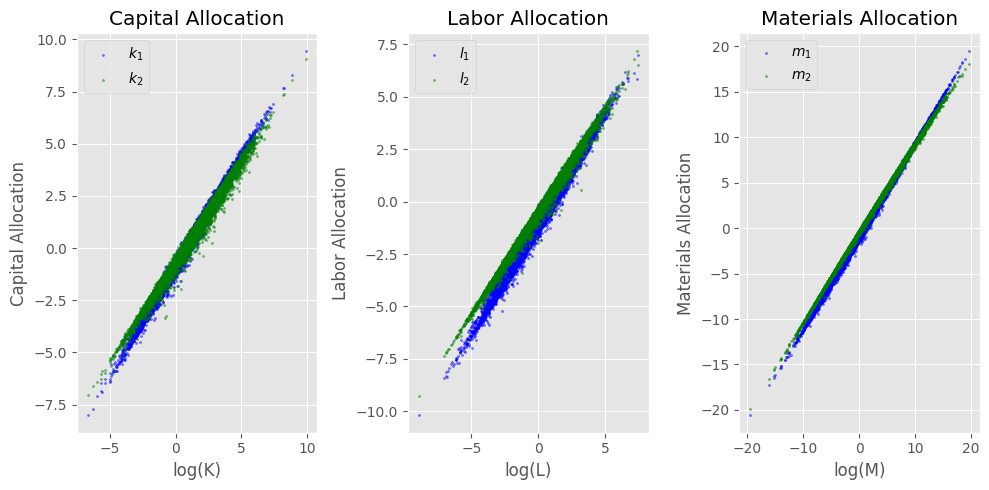

In [423]:
#visualize the input allocation 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.scatter(np.log(data[1][:,0:1]), Kopt[0], alpha=0.5, s=2,  label='$k_1$', color='blue')
plt.scatter(np.log(data[1][:,0:1]), Kopt[1], alpha=0.5, s=2, label='$k_2$', color='green')
plt.title('Capital Allocation')
plt.xlabel('log(K)')
plt.legend()
plt.ylabel('Capital Allocation')
plt.subplot(1, 3, 2)
plt.scatter(np.log(data[2][:,0:1]), Lopt[0], alpha=0.5, s=2, label='$l_1$', color='blue')
plt.scatter(np.log(data[2][:,0:1]), Lopt[1], alpha=0.5, s=2, label='$l_2$', color='green')
plt.title('Labor Allocation')
plt.legend()
plt.xlabel('log(L)')
plt.ylabel('Labor Allocation')
plt.subplot(1, 3, 3)
plt.scatter(np.log(data[3][:,0:1]), Mopt[0], alpha=0.5, s=2, label='$m_1$', color='blue')
plt.scatter(np.log(data[3][:,0:1]), Mopt[1], alpha=0.5, s=2, label='$m_2$', color='green')
plt.title('Materials Allocation')
plt.xlabel('log(M)')
plt.ylabel('Materials Allocation')
plt.tight_layout()
plt.legend()
plt.show()

In [529]:
# iteration on input shares to solve the problem 
def mp_input_shares(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # Material allocation parameter
    βm_2 = 1.0 - βl_2 - βk_2  # Material allocation parameter
    R, K, L, M = data  # Unpack the data
    n = len(K)  # Number of firms
    Lopt= [0.5*np.ones((n,1)), 0.5*np.ones((n,1))] # Initial guess for Labor allocation
    Kopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]# Initial guess for Capital allocation
    Mopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]  # Initial guess for Materials allocation
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    
    for i in range(max_iter):
        #compute output elasticities 
        γ_k = [v_1*βk_1* (Kopt[0]*K)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)), 
                v_2*βk_2* (Kopt[1]*K)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (Lopt[0]*L)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)),
                v_2*βl_2* (Lopt[1]*L)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # compute the input allocation shares 
        Kopt_new = [R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])]
        Lopt_new = [R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])]
        Mopt_new = [R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])]
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        
        if (np.linalg.norm(Lopt_new[0] - Lopt[0]) < tol and
            np.linalg.norm(Lopt_new[1] - Lopt[1]) < tol and
            np.linalg.norm(Kopt_new[0] - Kopt[0]) < tol and
            np.linalg.norm(Kopt_new[1] - Kopt[1]) < tol and
            np.linalg.norm(Mopt_new[0] - Mopt[0]) < tol and
            np.linalg.norm(Mopt_new[1] - Mopt[1]) < tol):
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        Lopt = Lopt_new
        Kopt = Kopt_new
        Mopt = Mopt_new
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist

In [426]:
# iteration to solve the input allocation problem
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_shares(params, data)

Converged to input allocations after 11 iterations.
CPU times: user 26.1 ms, sys: 14.5 ms, total: 40.6 ms
Wall time: 43.3 ms


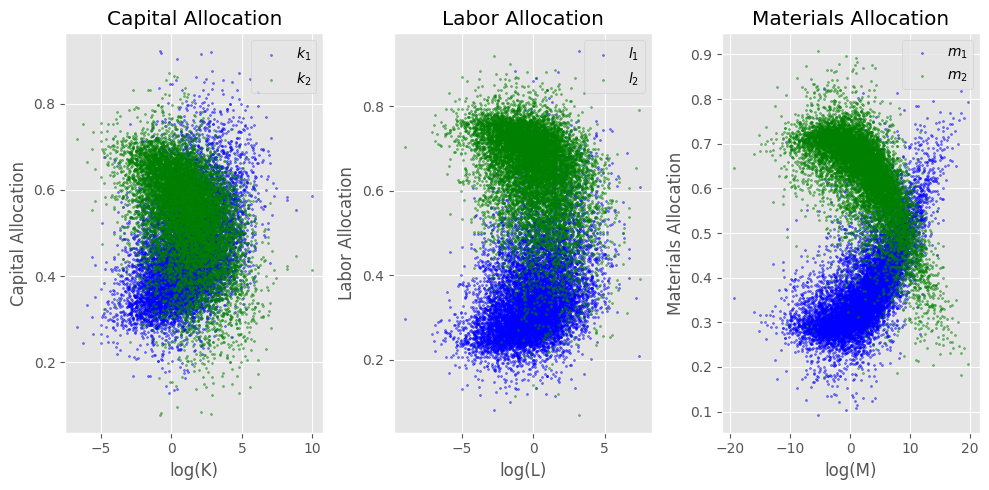

In [428]:
#visualize the input allocation 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.scatter(np.log(data[1][:,0:1]), Kopt[0], alpha=0.5, s=2,  label='$k_1$', color='blue')
plt.scatter(np.log(data[1][:,0:1]), Kopt[1], alpha=0.5, s=2, label='$k_2$', color='green')
plt.title('Capital Allocation')
plt.xlabel('log(K)')
plt.legend()
plt.ylabel('Capital Allocation')
plt.subplot(1, 3, 2)
plt.scatter(np.log(data[2][:,0:1]), Lopt[0], alpha=0.5, s=2, label='$l_1$', color='blue')
plt.scatter(np.log(data[2][:,0:1]), Lopt[1], alpha=0.5, s=2, label='$l_2$', color='green')
plt.title('Labor Allocation')
plt.legend()
plt.xlabel('log(L)')
plt.ylabel('Labor Allocation')
plt.subplot(1, 3, 3)
plt.scatter(np.log(data[3][:,0:1]), Mopt[0], alpha=0.5, s=2, label='$m_1$', color='blue')
plt.scatter(np.log(data[3][:,0:1]), Mopt[1], alpha=0.5, s=2, label='$m_2$', color='green')
plt.title('Materials Allocation')
plt.xlabel('log(M)')
plt.ylabel('Materials Allocation')
plt.tight_layout()
plt.legend()
plt.show()

In [490]:
##Experiments for Different kappa values 
params = mp_input_params(κ_1=0.5, κ_2=3) 
data = mp_data(params, n =1000)
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation(params, data)
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_shares(params, data)

TypeError: cannot unpack non-iterable NoneType object

CPU times: user 139 ms, sys: 5.6 ms, total: 144 ms
Wall time: 148 ms


### Modified Fixed-Point Iteration Algorithm

* Our previous algorithm directly applies the mapping $\mathbf{T}$ to the input allocation vector $\mathbf{x}_{ijt}^*$, which may not be a **contraction**. 

* The following algorithms slows down the iteration and iterating on the input shares: 
   $$ s_{ij}^{n+1} = (1-\lambda)s_{ij}^n + \lambda \frac{ P_{ij}Q_{ij}\gamma_j^x(\mathbf{s}_{ij}^{(n)}\bar{X}_{i})}{\sum_{j'}P_{ij'}Q_{ij'}{\gamma}_j^x (\mathbf{s}_{ij'}^{(n)}\bar{X}_{i})}$$
   * We choose $\lambda = \min\{1, \min_{j}\{\frac{\kappa_j}{2|\kappa_j-1|}\}\}$
   * Though not proved, the algorithm works well in a wide range of choices of $\kappa_j$. 

In [ ]:
def mp_input_share2(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # Material allocation parameter
    βm_2 = 1.0 - βl_2 - βk_2  # Material allocation parameter
    R, K, L, M = data  # Unpack the data
    n = len(K)  # Number of firms
    Lopt= [0.5*np.ones((n,1)), 0.5*np.ones((n,1))] # Initial guess for Labor allocation
    Kopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]# Initial guess for Capital allocation
    Mopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]  # Initial guess for Materials allocation
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    
    for i in range(max_iter):
        #compute output elasticities 
        γ_k = [v_1*βk_1* (Kopt[0]*K)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)), 
                v_2*βk_2* (Kopt[1]*K)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (Lopt[0]*L)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)),
                v_2*βl_2* (Lopt[1]*L)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # compute the input allocation shares
        Kopt_new = [R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])]
        Lopt_new = [R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])]
        Mopt_new = [R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])]
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        
        if (np.linalg.norm(Lopt_new[0] - Lopt[0]) < tol and
            np.linalg.norm(Lopt_new[1] - Lopt[1]) < tol and
            np.linalg.norm(Kopt_new[0] - Kopt[0]) < tol and
            np.linalg.norm(Kopt_new[1] - Kopt[1]) < tol and
            np.linalg.norm(Mopt_new[0] - Mopt[0]) < tol and
            np.linalg.norm(Mopt_new[1] - Mopt[1]) < tol):
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        α = 0.99* min([1, 0.5*κ_1/abs(κ_1-1), 0.5*κ_2/abs(κ_2-1)])  # Step size based on κ values
        Lopt = [α*Lopt_new[0] + (1-α)*Lopt[0], α*Lopt_new[1] +  (1-α)*Lopt[1]]
        Kopt = [α*Kopt_new[0] + (1-α)*Kopt[0], α*Kopt_new[1] +  (1-α)*Kopt[1]]
        Mopt = [α*Mopt_new[0] +  (1-α)*Mopt[0], α*Mopt_new[1] +  (1-α)*Mopt[1]]
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist    
        
def mp_input_allocation2(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # Material allocation parameter
    βm_2 = 1.0 - βl_2 - βk_2  # Material allocation parameter
    R, K, L, M = data  # Unpack the data
    Lopt= [0.5*np.log(L), 0.5*np.log(L)] # Initial guess for Labor allocation
    Kopt = [0.5*np.log(K), 0.5*np.log(K)] # Initial guess for Capital allocation
    Mopt = [0.5*np.log(M), 0.5*np.log(M)]  # Initial guess for Materials allocation
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    for i in range(max_iter):
        #compute output elasticities 
        γ_k = [v_1*βk_1* (np.exp(Kopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)), 
                v_2*βk_2* (np.exp(Kopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (np.exp(Lopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)),
                v_2*βl_2* (np.exp(Lopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # compute the input allocations 
        Kopt_new = np.log([K*R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), K*R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])])
        Lopt_new = np.log([L*R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), L*R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])])
        Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        if np.linalg.norm(Lopt_new - Lopt) < tol and np.linalg.norm(Kopt_new - Kopt) < tol and np.linalg.norm(Mopt_new-Mopt) < tol:
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        α = 0.99* min([1, 0.5*κ_1/abs(κ_1-1), 0.5*κ_2/abs(κ_2-1)])  # Step size based on κ values
        Lopt = [α*Lopt_new[0] + (1-α)*Lopt[0], α*Lopt_new[1] +  (1-α)*Lopt[1]]
        Kopt = [α*Kopt_new[0] + (1-α)*Kopt[0], α*Kopt_new[1] +  (1-α)*Kopt[1]]
        Mopt = [α*Mopt_new[0] +  (1-α)*Mopt[0], α*Mopt_new[1] +  (1-α)*Mopt[1]]
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt, Kopt, Mopt, Llist, Klist, Mlist

In [ ]:
import time
kappa1_list = np.arange(0.1, 6, 0.2)
kappa2_list = np.arange(0.1, 6, 0.2)
results = []
for κ_1 in kappa1_list:
    for κ_2 in kappa2_list:
        params = mp_input_params(κ_1=κ_1, κ_2=κ_2)
        data = mp_data(params, n=1000)
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_share2(params, data)
        iter1 = len(Llist)
        if iter1 < 1000:
            converged1 = True
        else:
            converged1 = False
        elapsed1 = time.time() - start
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_shares(params, data)
        iter2 = len(Llist)
        if iter2 < 1000:
            converged2 = True
        else:
            converged2 = False
        elapsed2 = time.time() - start
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation2(params, data)
        iter3 = len(Llist)
        if iter3 < 1000:
            converged3 = True
        else:
            converged3 = False
        elapsed3 = time.time() - start
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation(params, data)
        elapsed4 = time.time() - start
        iter4 = len(Llist)
        if iter4 < 1000:
            converged4 = True
        else:
            converged4 = False
        elapsed4 = time.time() - start
               
        results.append({
            'κ_1': κ_1,
            'κ_2': κ_2,
            'iterations1': iter1,
            'iterations2': iter2,
            'iterations3': iter3,
            'iterations4': iter4,
            'converged3': converged3,
            'converged1': converged1,
            'converged2': converged2,
            'converged4': converged4,
            'time1': elapsed1,
            'time2': elapsed2,
            'time3': elapsed3,
            'time4': elapsed4
        })

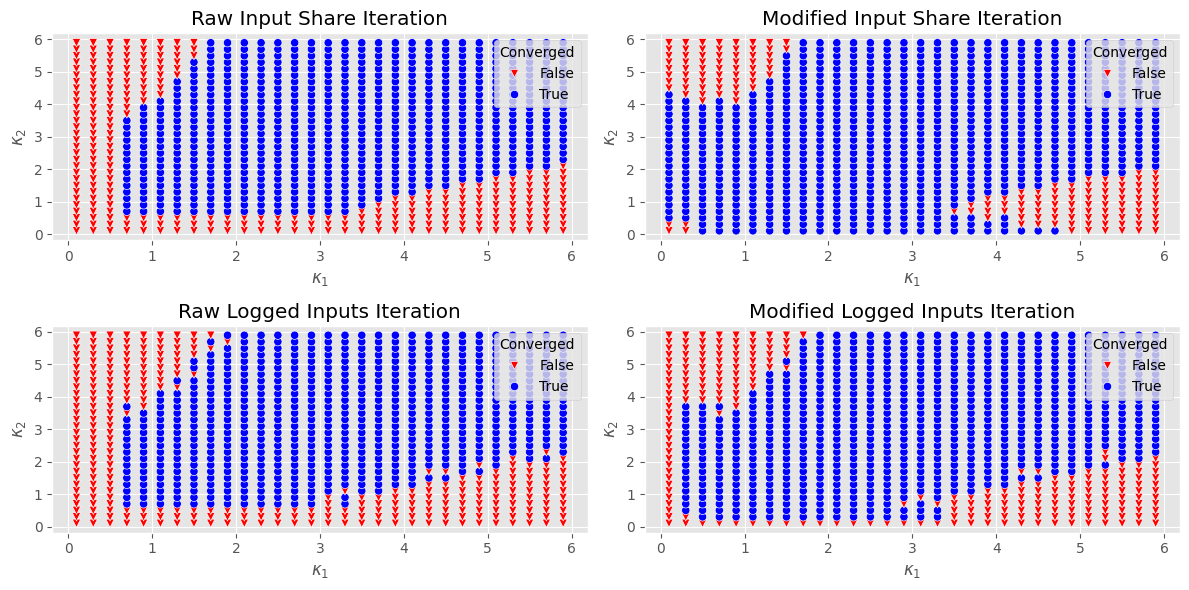

In [540]:
import pandas as pd 
import seaborn as sns
df_results = pd.DataFrame(results)
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 2)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged1',
	style='converged1',
	markers={True: 'o', False: 'v'},  # both filled markers
	palette={True: 'blue', False: 'red'}
)
plt.title('Modified Input Share Iteration')
plt.xlabel(r'$\kappa_1$')
plt.ylabel(r'$\kappa_2$')
plt.legend(title='Converged', loc='upper right')
plt.subplot(2, 2, 1)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged2',
	style='converged2',
	markers={True: 'o', False: 'v'},  # both filled markers
	palette={True: 'blue', False: 'red'}
)
plt.title('Raw Input Share Iteration')
plt.xlabel(r'$\kappa_1$')
plt.ylabel(r'$\kappa_2$')
plt.legend(title='Converged', loc='upper right')
plt.subplot(2, 2, 4)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged3',
	style='converged3',
	markers={True: 'o', False: 'v'},  # both filled markers
	palette={True: 'blue', False: 'red'}
)
plt.title('Modified Logged Inputs Iteration')
plt.xlabel(r'$\kappa_1$')
plt.ylabel(r'$\kappa_2$')
plt.legend(title='Converged', loc='upper right')
plt.subplot(2, 2, 3)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged4',
	style='converged4',
	markers={True: 'o', False: 'v'},  # both filled markers
	palette={True: 'blue', False: 'red'}
)
plt.title('Raw Logged Inputs Iteration')
plt.xlabel(r'$\kappa_1$')
plt.ylabel(r'$\kappa_2$')
plt.legend(title='Converged', loc='upper right')
plt.tight_layout()

plt.show()

> **Exercise 1 (Computing the Cournot Game)** 

Consider a Cournot Duopoly with the following setting: 
* Demand for the good is CES: $P(q) = q^{-1/\eta}$, where $q = q_1 + q_2$. 
* Each firm has quadratic costs: $C_i(q) = \frac{1}{2} c_i q_i^2$ for $i = 1,2$.Then firm $i$ solves the following maximization problem: $$ \max_{q_i} P(q_i + q_{-i})q_i - C_i(q_i) $$
Find equilibrium of this model by simultaneously solving both
    firms first order conditions, which will be nonlinear equations for $i = 1,2$:$$f_i(q) = (q_i + q_{-i})^{-1/\eta} - (1/\eta)(q_i + q_{-i})^{-1/\eta-1}q_i- c_iq_i = 0$$
* **Parameters**: $[c_1, c_2, \eta] = [0.3, 0.6, 2];$ 

You need to: 
  1. Solve the system of equations by writing your own code using the Newton's method for solving nonlinear equations. 
  2. Try a direct iteration method by finding the fixed point (Nash equilibrium) and experiment with different initial values. Explain your results by referencing the **theory of contraction mappings**.
  3. Use the `scipy.optimize.fsolve` function to solve the system of equations. 
  4. Now suppose that the government subsidizes firm 2 by reducing its production cost to be $C_2(q) = 0.9\times \frac{1}{2} c_2 q_i^2 $. How does the equilibrium change?

## Introduction to Structural Estimation in Economics
---

### A First Glance at Reduced-form and Structural Methods
---
#### Reduced-form Methods: 
  - Focus on estimating the causal effect of a treatment ($X$) on an outcome ($Y$).
  
  - Do not explicitly model the underlying mechanisms.
  
  - e.g., OLS, IV, RDD, matching, etc. 

#### Structural Methods: 
  - Focus on estimating the structural parameters of a model that describes the relationship between $X$ and $Y$.
  
  - Explicitly model the underlying mechanisms
  
  - Counterfactual analysis for policy evaluation and welfare analysis 
  
  - e.g., demand estimation, dynamic programming, quantitative trade models, etc.

### Connecting Model to Data: A Comparison
---


| Features | Reduced-form Model |  Structural Model |
|:---------:|:------------------:|:--------------------:|
| *Data Generation Process* |$Y_i = f(X_i) + \varepsilon_i$ | $X_i = argmax_{z} \{U(Y_i, z)\}$|
| *Estimation Purpose*| Causal effect of $X$ on $Y$ | Structural parameters of the model |
| *Estimation Method* | OLS, IV, RDD, Matching | SMM, MLE, MCMC |
| *Advantages* | Easy to implement, interpret, and understand | More flexible, can incorporate more information, can be used for counterfactual analysis |
| *Disadvantages* | mechanisms? mis-specification? General equilibrium effects? | Usually more complicated, requires more assumptions, overfitting problem|

### Routine Procedures of Structural Estimation

1. **Model Specification**: Define the economic model and its structural parameters.
   - Example: Demand estimation, production function estimation, etc.
2. **Data Collection**: Gather data relevant to the model.

3. **Model Estimation**: Estimate the structural parameters using the data.
   - Methods: Simulated Method of Moments (SMM), Maximum Likelihood Estimation (MLE), Bayesian methods, etc.

4. **Model Validation**: Check the model's fit to the data and its predictive power.

5. **Counterfactual Analysis**: Use the estimated model to conduct counterfactual analysis and policy evaluation.
   - Example: Simulate the effects of a policy change on the outcome variable.

6. **Sensitivity Analysis**: Check the robustness of the results to different assumptions and specifications.

### Basic Concepts in Structural Estimation

> **Model**: A **model** is a set of cause and effect mathematical relationships, often specified with parameters $\theta$, among data $x$ or $(x,y)$ used to understand, explain, and predict phenomena. A model might be specified as,
\begin{equation*}
  g(x,\theta) = 0 \quad\text{or}\quad y = g(x,\theta)
\end{equation*}
where $g$ is a function or vector of functions that represents the mathematical relationships between variables and parameters.

> **Exogenous Variable**: **Exogenous variables** are inputs to the model, taken as given, or from outside the model. These can include both data $x$ and parameters $\theta$.

> **Endogenous variables** are outputs of the model or dependent on exogenous variables. These can include portions of the data $x$, sometimes designated as $y$ as in $y = g(x,\theta)$.

## Estimation Methods in Structural Estimation 
---
### Maximum Likelihood Estimation (MLE)

### Generalized Method of Moments (GMM)

### Simulated Method of Moments (SMM)

**Reference**: https://opensourceecon.github.io/CompMethods/struct_est/intro.html

### Maximum Likelihood Estimation (MLE,极大似然法)
---
 Define a model or a **data generating process (DGP)** as,
$$
F(x_t, z_t|\theta) = 0
$$
where $x_t$ and $z_t$ are variables, $\theta$ is a vector of parameters, and $F(\cdot)$ is the function characterizing their relations.

* **MLE**: choose the parameter vector of the model $\theta$ to **maximize the likelihood of seeing the data** $(x_t, z_t)$ produced by the model $F(x_t, z_t|\theta) = 0$.

* `Rust (1987)` uses MLE (with nested fixed-point iteration) to estimate the parameters of a dynamic programming model of bus engine replacement. [`Python Package`](https://ruspy.readthedocs.io/en/latest/index.html)

### MLE Example: Normal Distribution 
* For the normal distribution, the (statistical) model is defined using the probability density function (PDF, 概率密度函数):$$
    f(x|\theta) = f(x|\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x - \mu)^2}{2\sigma^2}} $$
where $\theta = (\mu, \sigma)$, $\mu$ is the mean, and $\sigma$ is the standard deviation.  

* With *i.i.d* assumption, define the likelihood function of $N$ draws $(x_1,x_2,...x_N)$ from a model or distribution $f(x|\theta)$ as $\mathcal{L}$.$$  \mathcal{L}(x_1,x_2,...x_N|\theta) \equiv \prod_{i=1}^N f(x_i|\theta)$$

* It is usually easier to use the log likelihood function $\ln(\mathcal{L})$.
 $$  \ln\Bigl(\mathcal{L}(x_1,x_2,...x_N|\theta)\Bigr) \equiv \sum_{i=1}^N \ln\Bigl(f(x_i|\theta)\Bigr)$$


In [40]:
#Example of MLE for Normal Distribution
#parameterization 
normal_params = namedtuple("normal_params", ('mu', 'sigma'))
def create_normal_params(mu=1.5, sigma=3.5):
    return normal_params(mu=mu, sigma=sigma)
#generate data
def generate_data(mu, sigma, n=1000):
    np.random.seed(42)  # Set random seed for reproducibility
    data = np.random.normal(mu, sigma, n)
    return data
#log likelihood function
def log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:  # Ensure sigma is positive
        return np.inf
    n = len(data)
    ll = -n/2 * np.log(2 * np.pi) - n * np.log(sigma) - np.sum((data - mu)**2) / (2 * sigma**2)
    return -ll  # Return negative log likelihood for minimization

In [47]:
#use the scipy optimize library to find the MLE
from scipy.optimize import minimize
params_true = create_normal_params(mu=1, sigma=3)
data = generate_data(params_true.mu, params_true.sigma, n=5000)
initial_params = create_normal_params(mu=0.8, sigma=2)
mle_res = minimize(
    log_likelihood, 
    x0=np.array([initial_params.mu, initial_params.sigma]), 
    args=(data,),
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-6, None))  # sigma must be positive
)
print(mle_res)
print("True parameters (mu, sigma)=({:.4f}, {:.4f})".format(params_true.mu, params_true.sigma))
print("Estimated (mu, sigma)=({:.4f}, {:.4f})".format(mle_res.x[0], mle_res.x[1]))

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 12569.622155564306
        x: [ 1.017e+00  2.989e+00]
      nit: 5
      jac: [-3.820e-03  9.459e-02]
     nfev: 18
     njev: 6
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
True parameters (mu, sigma)=(1.0000, 3.0000)
Estimated (mu, sigma)=(1.0168, 2.9892)


### Generalized Method of Moments (GMM,广义矩量法)
---

* GMM was first formalized by {cite}`Hansen:1982`. A strength of GMM estimation is that the econometrician can remain completely agnostic as to the distribution of the random variables in the DGP. 
  
> **Data/Model Moment**: A **moment** of the data/model is broadly defined as any statistic that summarizes the data/model to some degree. E.g., mean, variance, covariance, etc.
\begin{aligned}
\text{data moments: }  & m(x) \equiv \left[m_1(x), m_2(x), ...m_{\ell}(x)\right]^T \\
\text{model moments: } & m(x|\theta) \equiv \left[m_1(x|\theta), m_2(x|\theta), ...m_{\ell}(x|\theta)\right]^T
\end{aligned}

**GMM Estimation**: The GMM approach is to choose $\theta$ to **minimize** some distance measure of the model moments $m(x|\theta)$ from the data moments $m(x)$:$$||m(x|\theta) - m(x)||$$

### GMM Estimator and Two-Step GMM
---
>**GMM Estimator**: Define $e(x|\theta) \equiv m(x|\theta) - m(x)$, the **GMM estimator** is given by:$$ \hat{\theta}_{GMM}=\argmin_{\theta}\:e(x|\theta)^\top \, W \, e(x|\theta)$$ where where $W$ is an $\ell \times \ell$ weighting matrix in the criterion function.

#### Choice of Weighting Matrix 
* The identity matrix: $W = I_\ell$ is a common choice, but it does not take into account the variance of the moments.

* The **optimal weighting matrix** is given by the inverse of the covariance matrix of the moments: $$W^* = \left[e(x|\theta)\cdot e(x\theta)^\top\right]^{-1}$$

#### Two-Step GMM Estimator 
The optimal weighting matrix is not known without knowing the parameters. This motivates the **two-step GMM estimator**:
>**Two-Step GMM Estimator**:
> 1. **Step 1**: Estimate the GMM parameter vector $\hat{\theta}_{1,GMM}$ using the simple identity matrix as the weighting matrix $W = I$ and obtain $\hat{\theta}_{1,GMM}$ and $\hat{e}(x|\hat{\theta}_{1,GMM})$.
> 2. **Step 2**: Construct the weighting matrix as $\widehat{W} = \left[\hat{e}(x|\theta)\cdot \hat{e}(x\theta)^\top\right]^{-1}$ and use the GMM estimator with $\widehat{W}$ to obtain the two-step GMM estimator $\hat{\theta}_{GMM}^{two-step}$.

#### Iterative GMM Estimator
As we have seen in many optimization algorithms, repeat the process described in the two-step GMM estimator *until the estimated weighting matrix no longer significantly changes between iterations*.
>**Iterative GMM Estimator**:
> 1. **Step 1**: Estimate the GMM parameter vector $\hat{\theta}_{1,GMM}$ using the simple identity matrix as the weighting matrix $W = I$ and obtain $\hat{\theta}_{1,GMM}$ and $\hat{e}(x|\hat{\theta}_{1,GMM})$.
> 2. **Remaining Steps**: Repeat the second step of the two-step GMM estimator until $$|| \hat{W}^{(k+1)} - \hat{W}^{(k)} || < \varepsilon$$

#### Inference in GMM 
Using the [**delta method**](https://en.wikipedia.org/wiki/Delta_method), we can derive the asymptotic distribution of the GMM estimator:
$$\text{plim}_{N\rightarrow\infty}\sqrt{N}\left(\hat{\theta}_{GMM} - \theta_0\right) \sim \text{N}\left(0, \left[\frac{\partial e(x|\theta)}{\partial \theta}^\top W \frac{\partial e(x|\theta)}{\partial \theta}\right]^{-1}\right)$$

* Instead of bootstrapping, we can use the above asymptotic distribution to construct confidence intervals for the GMM estimator.

### GMM Example: Normal Distribution 
* For data generated from the normal distribution, we choose mean and standard deviation as the moments:
  \begin{aligned}
    \text{data: } &m(x) =  \left[\frac{1}{n}\sum_i X_i, \sqrt{\frac{1}{n}\sum_i(X_i-\bar{X})^2}\right]^\top \\
   \text{model: } &m(\theta) = \left[\mu, \sigma\right]^\top
  \end{aligned}

* The GMM objective function is given by: 
 \begin{aligned}
 \small 
    \hat{\theta}_{GMM}&=\argmin_{\theta}\:[m(\theta)-m(x)] \, W \, [m(\theta)-m(x)]^\top 
\end{aligned}

* Experiment with Two-Step GMM and Iterative GMM. 

In [81]:
#GMM estimation for Normal Distribution 
def gmm_objective(params, data):
    """Objective function with Identity Weighting"""
    mu, sigma = params
    if sigma <= 0:  # Ensure sigma is positive
        return np.inf
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return np.sum(moments**2)
def gmm_weight(params, data):
    """Weighting matrix for GMM"""
    mu, sigma = params
    n = len(data)
    moments_matrix = np.stack([
        data - mu,
        (data - mu)**2 - sigma**2
    ], axis=1)
    Omega =1/n * np.cov(moments_matrix, rowvar=False)
    return np.linalg.pinv(Omega)  # 用伪逆更稳健    
def gmm_iter_objective(params, data, W):
    """Objective function with General Weighting Matrix"""
    mu, sigma = params
    if sigma <= 0:  # Ensure sigma is positive
        return np.inf
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return moments.T @ W @ moments

In [82]:
# Two-step GMM Estimation 
params_init = create_normal_params(mu=0.8, sigma=2)
x0 = np.array([params_init.mu, params_init.sigma])
# First step: Identity weighting matrix
gmm_res1 = minimize(
    gmm_objective, 
    x0=x0, 
    args=(data,), 
    method='L-BFGS-B', 
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-8, None))  # sigma must be positive
)
print("First step GMM results:", gmm_res1)

First step GMM results:   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 1.1931320913300125e-15
        x: [ 1.017e+00  2.989e+00]
      nit: 11
      jac: [-4.353e-10 -5.086e-08]
     nfev: 36
     njev: 12
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


In [ ]:
#Second-step: Compute the weighting matrix and re-estimate
W = gmm_weight(gmm_res1.x, data)
print("Estimated Second-Step Weighting Matrix:\n", W)
gmm_res2 = minimize(
    gmm_iter_objective, 
    x0=gmm_res1.x, 
    args=(data, W), 
    method='L-BFGS-B', 
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-8, None))  # sigma must be positive
)
print("Second step GMM results:", gmm_res2)
print("Weighting Matrix:\n", gmm_weight(gmm_res2.x, data))

Estimated Second-Step Weighting Matrix:
 [[559.52662993   1.09441854]
 [  1.09441854  30.69346586]]
Second step GMM results:   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 5.140816272492453e-14
        x: [ 1.017e+00  2.989e+00]
      nit: 0
      jac: [-3.183e-07 -1.629e-06]
     nfev: 3
     njev: 1
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
Weighting Matrix:
 [[559.52662993   1.09441854]
 [  1.09441854  30.69346586]]


In [91]:
# Inference for the GMM estimates
### Compute the derivatives of the moments wrt the parameters
import autograd.numpy as np
from autograd import jacobian
def gmm_moments(params):
    mu, sigma = params
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return moments
#use autograd to compute the Jacobian of the moments
gmm_jacobian = jacobian(gmm_moments)  # Compute the Jacobian wrt the first argument (params)
gmm_jacobian_val = gmm_jacobian(gmm_res2.x)  # Evaluate the Jacobian at the estimated parameters  
print(gmm_jacobian_val)

[[-1.          0.        ]
 [ 0.         -5.97828104]]


In [95]:
def gmm_vc(data, params):
    W = gmm_weight(gmm_res2.x, data)
    n = len(data)
    gmm_delta = gmm_jacobian(params)  # Evaluate the Jacobian at the estimated parameters
    CV = 1/n * np.linalg.inv(gmm_delta.T @ W @ gmm_delta)
    return CV
# Compute the variance-covariance matrix
theta_vc = gmm_vc(data, gmm_res2.x)
#make a table of estimated parameters and their standard errors
def gmm_results_table(params, vc_matrix):
    mu, sigma = params
    std_errors = np.sqrt(np.diag(vc_matrix))
    results = pd.DataFrame({
        'Parameter': ['mu', 'sigma'],
        'Estimate': [mu, sigma],
        'Std. Error': std_errors
    })
    return results

results_table = gmm_results_table(gmm_res2.x, theta_vc)
print("------Two-Step GMM Results-------")
print("---------------------------------")
print(results_table)

------Two-Step GMM Results-------
---------------------------------
  Parameter  Estimate  Std. Error
0        mu  1.016806    0.000598
1     sigma  2.989141    0.000427


In [98]:
#Iterative GMM Estimation 
def iterative_gmm_objective(params, data, W):
    """Objective function for iterative GMM"""
    mu, sigma = params
    if sigma <= 0:  # Ensure sigma is positive
        return np.inf
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return moments.T @ W @ moments

Tol = 1e-8
def iterative_gmm_estimation(data, params_init, tol=Tol, max_iter=1000):
    """Iterative GMM estimation with convergence check"""
    params = np.array([params_init.mu, params_init.sigma])
    W = gmm_weight(params, data)
    for i in range(max_iter):
        res = minimize(
            iterative_gmm_objective, 
            x0=params, 
            args=(data, W), 
            method='L-BFGS-B', 
            options={'disp': True, 'maxiter': 10000}, 
            bounds=((None, None), (1e-8, None))  # sigma must be positive
        )
        new_params = res.x
        new_W = gmm_weight(new_params, data)
        if np.linalg.norm(new_W - W) < tol:
            print(f"Converged after {i+1} iterations.")
            return new_params
        params = new_params
        W = new_W # Update the weighting matrix
    print("Warning: Maximum iterations reached without convergence.")
    return params


In [99]:
# iterative gmm estimation results 
iterative_params = iterative_gmm_estimation(data, params_init)
# Compute the variance-covariance matrix for the iterative GMM
theta_vc_iterative = gmm_vc(data, iterative_params)
# Make a table of estimated parameters and their standard errors for iterative GMM
iterative_results_table = gmm_results_table(iterative_params, theta_vc_iterative)
print("------Iterative GMM Results-------")
print("---------------------------------")
print(iterative_results_table)

Converged after 2 iterations.
------Iterative GMM Results-------
---------------------------------
  Parameter  Estimate  Std. Error
0        mu  1.016806    0.000598
1     sigma  2.989141    0.000427


### Simulated Method of Moments (SMM,模拟矩量法)
---
* **SMM** is a particular type of GMM estimator
* **Main Idea**: The SMM estimator chooses a vector of model parameters $\theta$ to make simulated model moments match data moments:
$$\hat{\theta}_{SMM}=\argmin_{\theta}\: ||\hat{m}(\tilde{x}|\theta)-m(x)||$$
   where $\hat{m}(\tilde{x}|\theta)$ are the simulated model moments based on the model parameters $\theta$ and the simulated data $\tilde{x}$. 

* **Simulated Model Moments**: The simulated model moments $\hat{m}(\tilde{x}|\theta)$ are computed from the simulated data $\tilde{x}$ using the same moment functions as in GMM.

* The objective function, weighting matrix, and inference are similar to GMM, the only difference is using **simulated data** $\tilde{x}$ instead of the actual data $x$.

* **Example**: `Eaton et al. (2012, Econometrica)` use SMM to quantify the Melitz model of international trade. [Reference Slides](https://gitee.com/zhiyuanryanchen/econ-research-methods/tree/master/2020Fall/Lecture5)


### Identification in Moments-Based Estimation

**General Rules of Identification**: Suppose the parameter vector $\theta$ has $k$ elements, or rather, $k$ parameters to be estimated. In order to estimate $\theta$ by GMM, you must have at least as many moments as parameters to estimate $\ell \geq k$. 

* **Exact Identification**: $\ell = k$, the model is *exactly identified*.
* **Over Identified**: $\ell > k$, the model is *overidentified*. 
* **Under Identified**: $\ell <k$, the model is *underidentified*.
  
There are good reasons to over-identify $\ell>k$ the model in SMM estimation as we saw in the previous example: 
* Some moments convey roughly the same information about the data and **do not separately identify any extra parameters**. 

* **Outside moment validation**: Take some moment from the data that was not used in the estimation and see how well the corresponding moment from the estimated model matches

> **Selection of Moments**: Choosing moments to estimate parameters by SMM requires **understanding of the model, intuition about its connections to the real world, and artistry**.

In [100]:
# Estimate Normal Distribution Parameters using SMM 
def smm_objective(params, data):
    """Simulate moments for SMM"""
    mu, sigma = params
    np.random.seed(42)  # Set random seed for reproducibility
    n = 10000  # Number of simulated data points
    simulated_data = np.random.normal(mu, sigma, n)
    m1 = np.mean(simulated_data) - np.mean(data)
    m2 = np.var(simulated_data) - np.var(data)
    moments = np.array([m1, m2])
    return np.sum(moments**2)
# SMM estimation
smm_res = minimize(
    smm_objective, 
    x0=np.array([params_init.mu, params_init.sigma]), 
    args=(data,), 
    method='L-BFGS-B', 
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-8, None))  # sigma must be positive
)
print("SMM results:", smm_res)
# Compute the variance-covariance matrix for SMM

SMM results:   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 1.6585624839823286e-12
        x: [ 1.023e+00  2.979e+00]
      nit: 9
      jac: [-2.556e-06 -9.438e-07]
     nfev: 30
     njev: 10
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


## Appendix 
---

### 1. Jacobian Matrix in Broyden Method 
---
<a id="Jacobian-Matrix-in-Broyden's-Method"></a>

Given:
- A matrix $J^{(k)} \in \mathbb{R}^{n \times n}$,
- Vectors $\Delta x^{(k)} \equiv x^{(k)}-x^{(k-1)}, \Delta f^{(k)}\equiv f({x^{(k)}})-f(x^{(k-1)}) \in \mathbb{R}^n$,
- Residual vector $r_k := J^{(k+1)}\cdot\Delta f^{(k)} - J^{(k)}\cdot \Delta f^{(k)} \in \mathbb{R}^n$,

We want to find a matrix $\Delta J^{(k)} \in \mathbb{R}^{n \times n}$ that:

1. **Satisfies the constraint:**
   $$
   \Delta J^{(k)} \cdot \Delta f^{(k)} = r_k
   $$

2. **Minimizes the Frobenius norm:**
   $$
   \min_{\Delta J^{(k)}} \|\Delta J^{(k)}\|_F^2
   $$

This is a constrained optimization problem.

---
#### Step 1: Vectorizing the Problem

Let’s consider the Frobenius norm:
$$
\|\Delta J^{(k)}\|_F^2 = \text{tr}((\Delta J^{(k)})^\top \Delta J^{(k)}) = \sum_{i,j} [\Delta J^{(k)}]_{ij}^2
$$

We minimize this subject to the constraint:
$$
\Delta J^{(k)} \Delta f^{(k)} = r_k
$$

Let’s denote: $A := \Delta J^{(k)}$, $y := \Delta f^{(k)}$, $r := r_k$.

---
#### Step 2: Use Lagrange Multipliers

We form the Lagrangian:
$$
\mathcal{L}(A, \lambda) = \frac{1}{2} \|A\|_F^2 - \lambda^\top (A y - r)
$$
where $\lambda \in \mathbb{R}^n$ is the Lagrange multiplier vector.

---
#### Step 3: Take Derivative w.r.t. $A$

The derivative of:
- $\frac{1}{2} \|A\|_F^2 = \frac{1}{2} \text{tr}(A^\top A)$ w.r.t. $A$ is $A$,
- $\lambda^\top A y = \text{tr}(\lambda y^\top A)$, so its derivative is $\lambda y^\top$.

So:
$$
\nabla_A \mathcal{L} = A - \lambda y^\top = 0 \quad \Rightarrow \quad A = \lambda y^\top
$$

---

#### Step 4: Plug into Constraint

Use the constraint $A y = r$. Plug in $A = \lambda y^\top$:
$$
\lambda y^\top y = r \quad \Rightarrow \quad \lambda = \frac{r}{y^\top y}
$$
---
#### Step 5: Final Expression for Update
Now substitute $\lambda$ back:
$$\Delta J^{(k)} = A = \lambda y^\top = \frac{r y^\top}{y^\top y} = \frac{(\Delta x^{(k)} - J^{(k)} \Delta f^{(k)}) (\Delta {f^{(k)}})^\top}{(\Delta {f^{(k)}})^\top \Delta f^{(k)}}$$

This gives the **minimum Frobenius norm matrix** $\Delta J^{(k)}$ satisfying $\Delta J^{(k)} \Delta f^{(k)} = \Delta x^{(k)} - J^{(k)} \Delta f^{(k)}$.

---

#### Final Update Rule

$$
J^{(k+1)} = J^{(k)} + \frac{(\Delta x^{(k)} - J^{(k)} \Delta f^{(k)}) (\Delta f^{(k)})^\top}{(\Delta f^{(k)})^\top \Delta f^{(k)}}
$$

Using the [Sherman-Morrison formula](https://blog.csdn.net/jclian91/article/details/80254568) to update directly the inverse of the Jacobian matrix: 

$$(J^k)^{-1} = (J^{k-1})^{-1}+\frac{\Delta x^k-(J^{k-1})^{-1}\Delta f^k}{(\Delta x^k)'(J^{k-1})^{-1}\Delta f^{k}}\Delta (x^k)'(J^k)^{-1}$$

This is the **Broyden "Good" update**.


### 2. Convergence Properties of Gradient Descent-based Method
---
#### The Steepest Descent Direction 
For $f: \mathbb{R}^n \rightarrow \mathbb{R}$, $\nabla f\in \mathbb{R}^n$ is the gradient.  The problem for the most *rapid descent direction* for $\ell-2$-norm is
$$
\min_{p\in \mathbb{R}^n} \nabla f(x)^T p \quad \text{s.t. } \|p\|_2 = 1
$$
The solution is $p = -\frac{\nabla f(x)}{\|\nabla f(x)\|_2}$, which is the **steepest descent direction**.
* The **steepest descent direction** may lead to slow convergence, especially near the minimum.
* In **Newton's method**, we use $p = -[H(x)]^{-1}\nabla f(x)$, where $H(x)$ is the Hessian matrix.

> Note: **The gradient descent-based algorithm** imposes that $f(x^{(k+1)}) \leq f(x^{(k)})$ for all $k$, BUT this simple conditions does not ensure the convergence to a minimize.

The following example illustrates it using `Python`. 

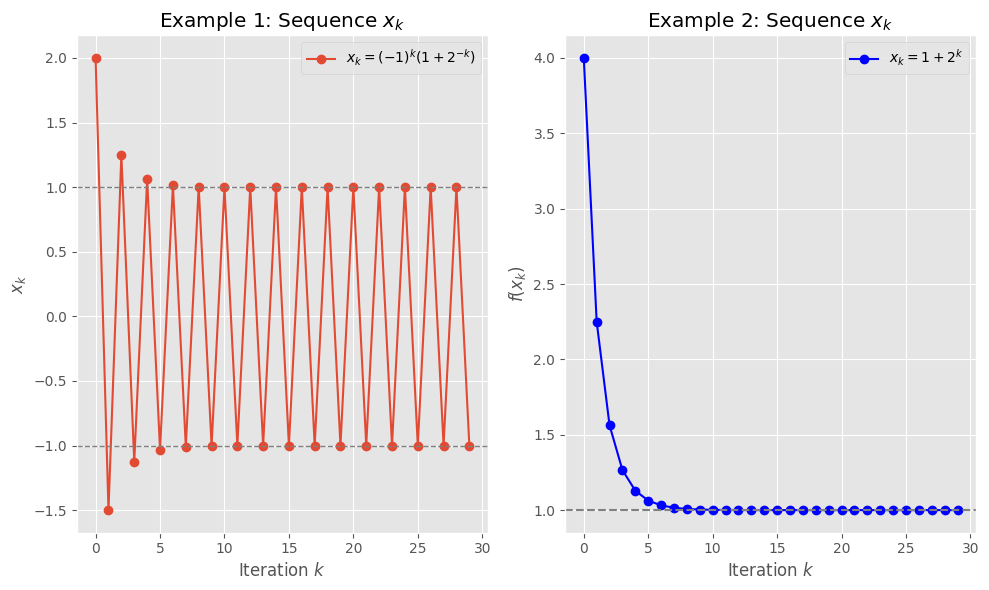

In [207]:
# Define the function f(x) = x^2
def f(x):
    return x**2
# Generate k values
k_vals = np.arange(0, 30)
# Example 1: Define x_k = (-1)^k * (1 + 2^{-k})
x_k = (-1)**k_vals * (1 + 2.0**(-k_vals))  # Use 2.0 to avoid ValueError
# Example 2: Define x_k = 1+2^-k 
x_k1 = 1 + 2.0**(-k_vals)  
# Evaluate f(x_k)
f_k = f(x_k)
f_k1 = f(x_k1)
# Plot x_k
plt.subplot(1, 2, 1)
plt.plot(k_vals, x_k, 'o-', label='$x_k = (-1)^k(1 + 2^{-k})$')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1)
plt.title('Example 1: Sequence $x_k$')
plt.xlabel('Iteration $k$')
plt.ylabel('$x_k$')
plt.grid(True)
plt.legend()
# Plot f(x_k)
plt.subplot(1, 2, 2)
plt.plot(k_vals, f_k1, 'o-', color='blue', label='$x_k = 1+2^{k}$')
plt.axhline(y=1, color='gray', linestyle='--')
plt.title('Example 2: Sequence $x_k$')
plt.xlabel('Iteration $k$')
plt.ylabel('$f(x_k)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Analysis of Example 1 
**Problem of Example 1**: We achieved very small decreases in $f$ values relative to *the length of steps*. This can be fixed by requiring that 
\begin{aligned}
f(x^{(k)}+\lambda p) \leq & f(x^{(k)}) + \alpha \lambda \nabla f(x^{(k)})^\top p \\
\Leftrightarrow \quad f(x^{(k+1)}) \leq & f(x^{(k)}) + \alpha \nabla f(x^{(k)})^\top (x^{(k+1)} - x^{(k)}), \quad \text{for } \alpha\in (0,1)
\end{aligned}

---

#### Analysis of Example 2 
**Problem of Example 2**: The steps are too small, relative to the initial rate of decrease of $f$. This can be fixed by requiring that
\begin{aligned}
f(x^{(k)}+\lambda p) \geq & f(x^{(k)}) + \beta \lambda \nabla f(x^{(k)})^\top p \\
\Leftrightarrow \quad f(x^{(k+1)}) \geq & f(x^{(k)}) + \beta \nabla f(x^{(k)})^\top (x^{(k+1)} - x^{(k)}), \quad \text{for } \beta \in (0,1)
\end{aligned}


## References 

* Eaton, Jonathan, Samuel Kortum, and Francis Kramarz. "An anatomy of international trade: Evidence from French firms." Econometrica 79.5 (2011): 1453-1498.

* Rust, John. "Optimal replacement of GMC bus engines: An empirical model of Harold Zurcher." Econometrica: Journal of the Econometric Society (1987): 999-1033.
  
* Richard W. Evans [Computational Methods for Economists using Python](https://opensourceecon.github.io/CompMethods/index.html) (Incomplete)

* [Math] (Chapter 5) Oden, J.T., Demkowicz, L.F.,  Applied Functional Analysis, 3rd Edition, 2018

* Magnus, Jan R., and Heinz Neudecker. Matrix differential calculus with applications in statistics and econometrics. John Wiley & Sons, 2019.
  
* Stanford University CS224N: Natural Language Processing with Deep Learning, https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1246/ 

* UC-Berkely:  [Python Programming And Numerical Methods: A Guide For Engineers And Scientists — Python Numerical Methods](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html) 
  
* Godoy, Daniel Voigt. [Deep Learning with PyTorch Step-by-step: A Beginner's Guide. Fundamentals. 2022.](https://github.com/dvgodoy/PyTorchStepByStep)

* Indranil Ghosh, [Introduction to Mathematical Optimization](https://indrag49.github.io/Numerical-Optimization/), 2021, gitbook. 

* Rick Rubin, [The Way of Code: The Timeless Art of Vibe Coding](https://www.thewayofcode.com/)

* Thomas J. Sargent and John Stachurski, [Python Programming for Economics and Finance](https://python-programming.quantecon.org/intro.html)